# F1 2026 Bahrain Preseason Testing 1 & 2 Baseline Benchmarking Analysis

## Introduction

This notebook analyzes Bahrain Preseason Testing 1 & 2 data to build an objective baseline of early-season car and driver behavior. The workflow combines data preparation, exploratory diagnostics, and modeling to explain lap-time variation under controlled assumptions.

The analysis focus is intentionally practical and engineering-oriented: baseline car performance benchmarking, driver consistency and adaptation analysis, and tyre behaviour with degradation modelling.

### Event Context

Bahrain International Circuit rewards strong traction and stability under braking into Turn 1, a 135-degree right-hander reached after a roughly 1.1 km full-throttle run, where speeds drop from around 330 km/h to 70 km/h along with mechanical grip through the technical, winding middle sector and aerodynamic efficiency across the circuit's three long straights. That makes lap time sensitive to tyre degradation on the circuit's notably abrasive, heat-retentive desert asphalt, heavy braking zones repeated at Turns 4, 8, 10, 11 and 12, sand ingestion affecting cooling and grip levels, and the setup compromise between low-downforce efficiency for the straights and the mechanical grip needed for the sinuous sections.

![Bahrain International Circuit layout](2026tracksakhirdetailed.png)

| Circuit Length (KM) | Number of Turns | First Grand Prix | Fastest Lap Time | Driver | Team | Year |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 5.412 | 15 | 2004 | 1:31.447 (91.447 sec) | Pedro de la Rosa | McLaren | 2005 |

### Research Objectives

1. Establish a baseline car performance benchmark across teams, sessions, compounds, and tyre life.
2. Quantify driver consistency and adaptation by tracking pace stability and session-to-session convergence.
3. Model tyre behaviour and degradation trends to understand lap-time sensitivity across stint progression.

## Data Preparation

This section loads the Bahrain Preseason Testing 1 & 2 sessions, checks whether local exports already exist, and rebuilds the dataset from FastF1 only when needed. The intent is to keep the notebook reproducible and fast to rerun while preserving a clear path from source data to benchmarking and modelling inputs.

In [1]:
# Importing libraries for data analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
import seaborn as sns
import fastf1 as ff1
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from itertools import product
from IPython.display import display

# Define testing metadata once and reuse across notebook
year = 2026
constructor_champion = 'McLaren' # Current constructor champion set as 100% as reference
tests = [1, 2]  # Bahrain Preseason Testing 1 & 2
session_day = {'Day1': 1, 'Day2': 2, 'Day3': 3}
session_names = list(session_day.keys())
cache_tag = f"testing_{'&'.join(map(str, tests))}"
cache_data = f"./f1_{year}_{cache_tag}_cache"
pre_clean_data = f"./f1_{year}_{cache_tag}_pre_clean_data"
plots = f"./f1_{year}_{cache_tag}_plots"

# Define CSV file paths
csv_file = f"{pre_clean_data}/f1_{year}_{cache_tag}_combined_laps.csv"
cleaned_csv_file = f"f1_{year}_{cache_tag}_cleaned_laps.csv"

# Prepare cache
os.makedirs(cache_data, exist_ok=True)
os.makedirs(pre_clean_data, exist_ok=True)
ff1.Cache.enable_cache(cache_data)

# Save figures to dedicated folders
os.makedirs(plots, exist_ok=True)
def save_figure(fig, filename):
    fig.savefig(os.path.join(plots, filename), dpi=150, bbox_inches='tight')

# Extract weather features from session and merge onto laps dataframe
def extract_weather_features(session, laps_df):
    thermal_cols = ['TrackTemp', 'AirTemp', 'Humidity']

    try:
        weather = session.weather_data.copy()
        if weather is None or weather.empty:
            for col in thermal_cols:
                laps_df[col] = np.nan
            return laps_df

        # Normalise weather index to a plain Time column (timedelta from session start)
        if 'Time' not in weather.columns:
            weather = weather.reset_index().rename(columns={'index': 'Time'})

        weather = weather[['Time'] + [c for c in thermal_cols if c in weather.columns]].copy()
        weather['Time'] = pd.to_timedelta(weather['Time'], errors='coerce')
        weather = weather.dropna(subset=['Time']).sort_values('Time').reset_index(drop=True)

        # Use LapStartTime as the join key; fall back to silence if missing
        if 'LapStartTime' not in laps_df.columns:
            for col in thermal_cols:
                laps_df[col] = np.nan
            return laps_df

        laps_df = laps_df.copy()
        laps_df['_LapStartTimeDelta'] = pd.to_timedelta(laps_df['LapStartTime'], errors='coerce')

        merged = pd.merge_asof(
            laps_df.sort_values('_LapStartTimeDelta'),
            weather,
            left_on='_LapStartTimeDelta',
            right_on='Time',
            direction='nearest'
        )

        # Re-align index so assignment back to the original order is safe
        merged = merged.sort_index()
        for col in thermal_cols:
            if col in merged.columns:
                laps_df[col] = merged[col].values
            else:
                laps_df[col] = np.nan

        laps_df = laps_df.drop(columns=['_LapStartTimeDelta'], errors='ignore')
        print(f"  Weather join: TrackTemp range "
              f"{laps_df['TrackTemp'].min():.1f}–{laps_df['TrackTemp'].max():.1f} °C "
              f"across {laps_df['TrackTemp'].notna().sum()} laps.")

    except Exception as exc:
        print(f"  Warning: weather feature extraction failed ({exc}). Columns set to NaN.")
        for col in thermal_cols:
            laps_df[col] = np.nan

    return laps_df

# Shared session cache for downstream telemetry/map analysis
sessions_by_name = {}
session_laps_by_name = {}

def load_sessions_once(load_telemetry=True):
    for test_no in tests:
        for session_name in session_names:
            cache_key = f"T{test_no}_{session_name}"
            if cache_key in session_laps_by_name:
                continue
            try:
                day = session_day[session_name]
                print(f"Loading Testing {test_no} Day {day} as {session_name}")
                session = ff1.get_testing_session(year, test_no, day)
                session.load(telemetry=load_telemetry, weather=True, messages=False)

                # Keep one canonical session per day for downstream telemetry blocks.
                if session_name not in sessions_by_name:
                    sessions_by_name[session_name] = session

                session_laps = session.laps.copy()
                session_laps['Session'] = session_name
                session_laps = extract_weather_features(session, session_laps)
                session_laps['Test'] = test_no
                session_laps_by_name[cache_key] = session_laps

                print(f"Loaded {len(session.laps)} laps from Testing {test_no} Day {day}")
            except Exception as exc:
                print(f"Info: Testing {test_no} Day {session_day[session_name]} failed to load ({exc}). Skipping.")

def build_and_save_combined_laps():
    load_sessions_once(load_telemetry=True)
    all_laps = [session_laps_by_name[key] for key in sorted(session_laps_by_name.keys())]

    if len(all_laps) == 0:
        raise RuntimeError(
            f"No testing days in tests={tests} and sessions={session_names} could be loaded. "
            "Please check FastF1 cache/network availability or provide the combined CSV file."
        )

    combined_data = pd.concat(all_laps, ignore_index=True)
    combined_data.to_csv(csv_file, index=False)
    print(f"\nData saved to {csv_file}")
    print(f"Total laps in dataset: {len(combined_data)}")
    return combined_data

# Check if CSV file already exists
if os.path.exists(csv_file):
    print(f"Loading data from existing CSV file: {csv_file}")
    data = pd.read_csv(csv_file)
    if 'Test' not in data.columns:
        print("Existing CSV is missing the 'Test' column. Rebuilding merged Testing 1 & 2 dataset from FastF1.")
        data = build_and_save_combined_laps()
    else:
        print(f"Total laps in dataset: {len(data)}")
        print("Preparing session cache for telemetry and race map")
        load_sessions_once(load_telemetry=True)

    print("Re-running weather feature extraction on cached practice data...")
    load_sessions_once(load_telemetry=False)   # telemetry=False keeps this fast
    for session_name in session_names:
        session = sessions_by_name.get(session_name)
        if session is None:
            continue
        mask = data['Session'] == session_name
        if not mask.any():
            continue
        subset = data.loc[mask].copy()
        # Restore LapStartTime temporarily from the raw session laps for the join key
        raw_laps = session.laps.copy()
        raw_laps['Session'] = session_name
        if 'LapStartTime' in raw_laps.columns and 'LapStartTime' not in subset.columns:
            # Match on Driver + LapNumber to bring LapStartTime back in
            key_cols = ['Driver', 'LapNumber']
            subset = subset.merge(
                raw_laps[key_cols + ['LapStartTime']].drop_duplicates(subset=key_cols),
                on=key_cols, how='left'
            )
        enriched = extract_weather_features(session, subset)
        for col in ['TrackTemp', 'AirTemp', 'Humidity']:
            if col in enriched.columns:
                data.loc[mask, col] = enriched[col].values
    print("Weather re-attachment complete.")
else:
    print("CSV file not found. Pulling Testing 1 & 2 data from FastF1")
    data = build_and_save_combined_laps()

Loading data from existing CSV file: ./f1_2026_testing_1&2_pre_clean_data/f1_2026_testing_1&2_combined_laps.csv
Total laps in dataset: 7137
Preparing session cache for telemetry and race map
Loading Testing 1 Day 1 as Day1


core           INFO 	Loading data for Pre-Season Testing - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	No lap data for driver 6
core        WARNING 	Fixed incorrect tyre stint information for driver '11'
core        WARNING 	No lap data for driver 14
core        WARNING 	No lap data for driver 30
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core        WARNING 	Fixed incorrect tyre stint information for driver '

  Weather join: TrackTemp range 24.7–40.7 °C across 1128 laps.
Loaded 1128 laps from Testing 1 Day 1
Loading Testing 1 Day 2 as Day2


req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	No lap data for driver 3
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 31
core        WARNING 	Fixed incorrect tyre stint information for driver '41'
core        WARNING 	No lap data for driver 43
core        WARNING 	No lap data for driver 44
core        WARNING 	Fixed incorrect tyre stint information for driver '55'
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core        WARNING 	Fixed incorrect tyre stint informa

  Weather join: TrackTemp range 23.7–40.4 °C across 1063 laps.
Loaded 1063 laps from Testing 1 Day 2
Loading Testing 1 Day 3 as Day3


...

  Weather join: TrackTemp range 24.7–41.7 °C across 1069 laps.
Loaded 1069 laps from Testing 2 Day 1
Loading Testing 2 Day 2 as Day2


req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	No lap data for driver 6
core        WARNING 	No lap data for driver 10
core        WARNING 	Fixed incorrect tyre stint information for driver '11'
core        WARNING 	Fixed incorrect tyre stint information for driver '12'
core        WARNING 	No lap data for driver 16
core        WARNING 	No lap data for driver 18
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	No lap data for driver 41
core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core        WARNING 	No lap data for driver 55
core   

  Weather join: TrackTemp range 26.7–45.7 °C across 1278 laps.
Loaded 1278 laps from Testing 2 Day 2
Loading Testing 2 Day 3 as Day3


core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	No lap data for driver 14
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	No lap data for driver 23
core        WARNING 	No lap data for driver 30
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '41'
core        WARNING 	No lap data for driver 43
core        WARNING 	No lap data for driver 44
core        WARNING 	Fixed incorrect tyre stint information for driver '55'
core        WARNING 	Fixed incorrect tyre stint information for driver '77'
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core    

  Weather join: TrackTemp range -16.5–46.3 °C across 1334 laps.
Loaded 1334 laps from Testing 2 Day 3
Re-running weather feature extraction on cached practice data...
  Weather join: TrackTemp range 24.7–40.7 °C across 2197 laps.
  Weather join: TrackTemp range nan–nan °C across 0 laps.
Weather re-attachment complete.


### Data Preprocessing

This preprocessing step standardizes lap-level records before analysis.

1. Convert timing fields to numeric seconds.
2. Remove deleted or inaccurate laps that would distort pace comparisons.
3. Drop columns that are not required for this notebook's analysis path.
4. Export the cleaned dataset so the processed source can be reused consistently.

In [2]:
# Cleaning the data
def data_cleaning(data, output_csv_path):
    cleaned_data = data.copy()

    # Convert all time columns to seconds
    time_columns = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    for col in time_columns:
        if col in cleaned_data.columns:
            # If already numeric (seconds), keep as-is
            if pd.api.types.is_numeric_dtype(cleaned_data[col]):
                cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')
            else:
                # Handle strings/timedelta-like values
                cleaned_data[col] = pd.to_timedelta(cleaned_data[col], errors='coerce').dt.total_seconds()

    # Remove deleted laps (commonly deleted for track limits)
    if 'Deleted' in cleaned_data.columns:
        deleted_mask = cleaned_data['Deleted'].astype(str).str.lower().isin(['true', '1', 'yes'])
        removed_count = int(deleted_mask.sum())
        cleaned_data = cleaned_data.loc[~deleted_mask].copy()
        print(f"Removed {removed_count} deleted laps.")

    # Remove inaccurate laps (e.g., those with missing or zero lap times)
    if 'IsAccurate' in cleaned_data.columns:
        accurate_mask = cleaned_data['IsAccurate'].astype(str).str.lower().isin(['false', '0', 'no'])
        accurate_count = int(accurate_mask.sum())
        cleaned_data = cleaned_data.loc[~accurate_mask].copy()
        print(f"Removed {accurate_count} inaccurate laps.")

    # Remove laps with unknown tyre compounds
    if 'Compound' in cleaned_data.columns:
        compound_mask = cleaned_data['Compound'].str.lower().isin(['unknown', 'test_unknown'])
        compound_count = int(compound_mask.sum())
        cleaned_data = cleaned_data.loc[~compound_mask].copy()
        print(f"Removed {compound_count} laps with missing or unknown tyre compounds.")

    # Drop unnecessary columns (if any)
    columns_to_drop = ['Time', 'PitOutTime', 'PitInTime', 'PitDuration', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                       'LapStartDateTime', 'LapStartDate', 'LapEndDateTime','Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
    cleaned_data = cleaned_data.drop(columns=[col for col in columns_to_drop if col in cleaned_data.columns])

    # Save the cleaned dataframe to a CSV file
    cleaned_data.to_csv(output_csv_path, index=False)
    print(f"Cleaned data saved to {output_csv_path}")
    return cleaned_data

df = data_cleaning(data, cleaned_csv_file)

Removed 0 deleted laps.
Removed 2519 inaccurate laps.
Removed 175 laps with missing or unknown tyre compounds.
Cleaned data saved to f1_2026_testing_1&2_cleaned_laps.csv


### Data Inspection

The inspection cells check that the cleaned dataset is structurally sound before any EDA or modeling begins. They confirm the table size, available columns, lap-time distribution, and the team-driver coverage that the later sections rely on.

In [3]:
# Display all data
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist())

# Display the dataframe
df

Total rows: 4443
Total columns: 24

Column names:
['Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'TrackStatus', 'Session', 'Test', 'TrackTemp', 'AirTemp', 'Humidity']


,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,...,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Session,Test,TrackTemp,AirTemp,Humidity
13,NOR,1,97.568,14.0,7.0,30.706,42.929,23.933,224.0,236.0,...,14.0,False,McLaren,0 days 06:59:03.283000,1.0,Day1,1,30.9,25.8,27.7
16,NOR,1,96.896,17.0,8.0,30.546,43.111,23.239,232.0,235.0,...,2.0,True,McLaren,0 days 07:19:39.060000,1.0,Day1,1,31.0,25.9,27.6
17,NOR,1,136.478,18.0,8.0,43.344,60.573,32.561,68.0,149.0,...,3.0,True,McLaren,0 days 07:21:15.956000,1.0,Day1,1,31.0,25.9,27.6
18,NOR,1,126.305,19.0,8.0,41.829,55.741,28.735,160.0,191.0,...,4.0,True,McLaren,0 days 07:23:32.434000,1.0,Day1,1,31.0,25.9,27.6
19,NOR,1,95.581,20.0,8.0,30.239,42.110,23.232,232.0,237.0,...,5.0,True,McLaren,0 days 07:25:38.739000,1.0,Day1,1,30.1,25.8,27.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7111,BEA,87,95.381,63.0,8.0,30.275,41.758,23.348,222.0,243.0,...,5.0,False,Haas F1 Team,0 days 07:46:19.425000,1.0,Day3,2,NaN,NaN,NaN
7114,BEA,87,93.959,66.0,9.0,29.830,41.125,23.004,227.0,244.0,...,2.0,True,Haas F1 Team,0 days 07:54:55.489000,1.0,Day3,2,NaN,NaN,NaN
7119,BEA,87,93.920,71.0,11.0,29.734,41.066,23.120,227.0,244.0,...,2.0,True,Haas F1 Team,0 days 08:09:14.016000,1.0,Day3,2,NaN,NaN,NaN
7124,BEA,87,93.520,76.0,13.0,29.757,40.758,23.005,227.0,244.0,...,2.0,True,Haas F1 Team,0 days 08:26:49.450000,1.0,Day3,2,NaN,NaN,NaN


In [4]:
# Display basic info
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nLapTime statistics:")
print(df['LapTime'].describe())

Dataset shape after cleaning: (4443, 24)

LapTime statistics:
count    4443.000000
mean      102.890869
std         9.907241
min        91.992000
25%        98.457000
50%       100.083000
75%       101.950500
max       149.876000
Name: LapTime, dtype: float64


In [5]:
# Display available teams and drivers
print("Available Teams:")
print(df['Team'].unique())
print("\nAvailable Drivers:")
print(df[['Driver', 'DriverNumber', 'Team']].drop_duplicates().sort_values('Team').reset_index(drop=True))

Available Teams:
['McLaren' 'Red Bull Racing' 'Audi' 'Alpine' 'Cadillac' 'Mercedes'
 'Ferrari' 'Aston Martin' 'Williams' 'Haas F1 Team' 'Racing Bulls']

Available Drivers:
   Driver  DriverNumber             Team
0     GAS            10           Alpine
1     COL            43           Alpine
2     ALO            14     Aston Martin
3     STR            18     Aston Martin
4     BOR             5             Audi
5     HUL            27             Audi
6     PER            11         Cadillac
7     BOT            77         Cadillac
8     LEC            16          Ferrari
9     HAM            44          Ferrari
10    OCO            31     Haas F1 Team
11    BEA            87     Haas F1 Team
12    PIA            81          McLaren
13    NOR             1          McLaren
14    RUS            63         Mercedes
15    ANT            12         Mercedes
16    LAW            30     Racing Bulls
17    LIN            41     Racing Bulls
18    HAD             6  Red Bull Racing
19    VE

In [6]:
# Set palettes
tyre_palette = {'SOFT': '#FF0000', 'MEDIUM': '#FFD400', 'HARD': '#FFFFFF',
                'INTERMEDIATE': '#4bff00', 'WET': '#0000FF'
                }

team_palette = {'Mercedes': '#00D2BE', 'Red Bull Racing': '#1E5BC6', 'Ferrari': '#DC0000',
                'McLaren': '#FF8700', 'Aston Martin': '#006F62', 'Alpine': '#0090FF',
                'Williams': '#005AFF', 'Racing Bulls': '#6692FF', 'Haas F1 Team': '#B6BABD',
                'Audi': '#7A7A7A', 'Cadillac': '#003B5C'
                }

driver_palette = {'LEC': '#DC0000', 'HAM': '#FFF200', 'NOR': '#FF8700', 'PIA': '#000000',
                  'RUS': '#00D2BE', 'ANT': '#C0C0C0', 'VER': '#1E5BC6', 'HAD': '#4C9BFF',
                  'ALB': '#005AFF', 'SAI': '#3A86FF', 'OCO': '#B30000', 'BEA': '#FF4D4D',
                  'LIN': '#2B3B6E', 'LAW': '#E63946', 'GAS': '#0090FF', 'COL': '#FF69B4',
                  'HUL': '#B6BABD', 'BOR': '#FF0000', 'ALO': '#006F62', 'STR': '#00FF9D',
                  'PER': '#003C71', 'BOT': '#A0A0A0',
                  }

# Display palette tables with visible color swatches
def display_palette_table(title, palette_dict):
    df_palette = pd.DataFrame(
        [(name, hex_color) for name, hex_color in palette_dict.items()],columns=['Name', 'Hex']
)

    styled = df_palette.style.apply(
        lambda row: [
            f"background-color: {row['Hex']}; color: black; font-weight: bold;" if col == 'Hex' else ''for col in row.index
            ],axis=1
        )

    print(title)
    display(styled.hide(axis='index'))
    print()

display_palette_table('Tyre Compound Palette', tyre_palette)
display_palette_table('Team Palette', team_palette)
display_palette_table('Driver Palette', driver_palette)

Tyre Compound Palette


Name,Hex
SOFT,#FF0000
MEDIUM,#FFD400
HARD,#FFFFFF
INTERMEDIATE,#4bff00
WET,#0000FF



Team Palette


Name,Hex
Mercedes,#00D2BE
Red Bull Racing,#1E5BC6
Ferrari,#DC0000
McLaren,#FF8700
Aston Martin,#006F62
Alpine,#0090FF
Williams,#005AFF
Racing Bulls,#6692FF
Haas F1 Team,#B6BABD
Audi,#7A7A7A



Driver Palette


Name,Hex
LEC,#DC0000
HAM,#FFF200
NOR,#FF8700
PIA,#000000
RUS,#00D2BE
ANT,#C0C0C0
VER,#1E5BC6
HAD,#4C9BFF
ALB,#005AFF
SAI,#3A86FF


## Exploratory Data Analysis

The EDA section examines pace distribution, session progression, stint structure, straight-line speed, telemetry shape, tyre effects, and degradation behavior. These checks provide the domain context needed to judge whether the feature set is informative enough for machine learning.

### Lap Time Distribution

Distribution plots show how each team's lap times are spread across the practice weekend. The center of each distribution reflects competitive pace, while the tails capture traffic, out-laps, in-laps, cooldowns, and other non-push contexts.

Comparing histograms with boxplots is useful here because two teams can share similar medians while differing materially in variability. That difference matters for prediction error and for interpreting how stable each team's practice pace really was.

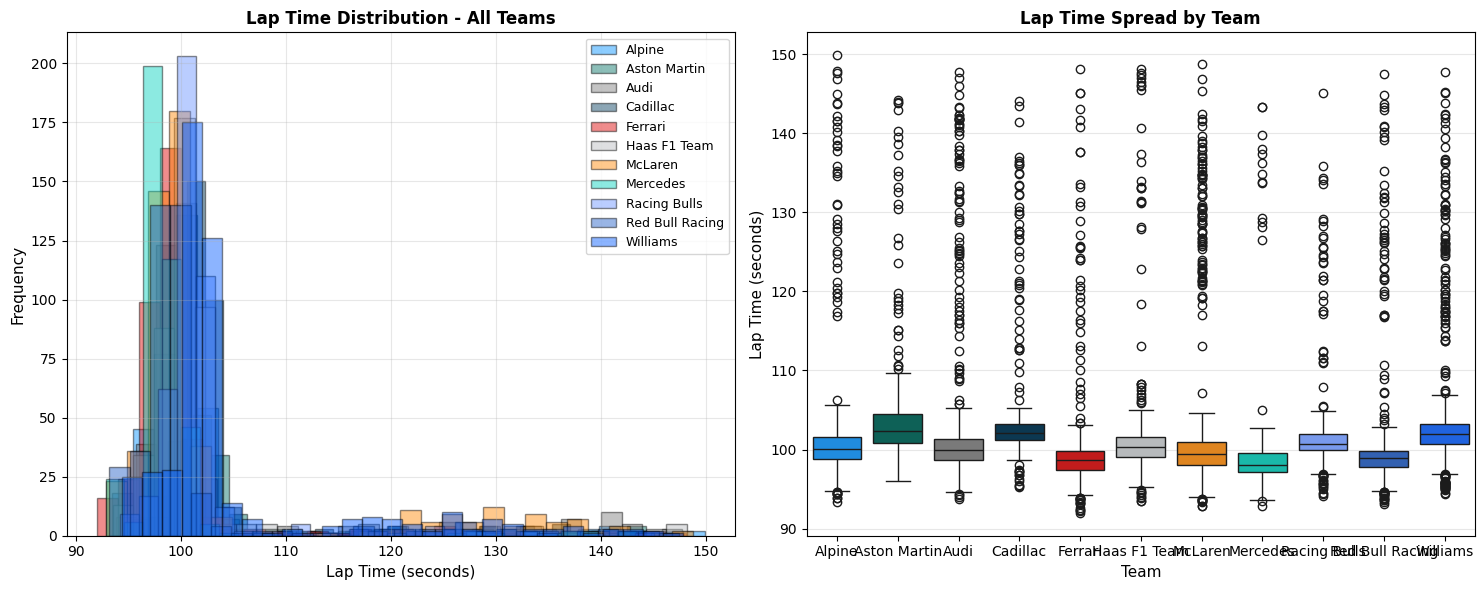

Team Lap Time Summary:
                 count     mean     min     std
Team                                           
Alpine             378  103.016  93.421  10.798
Aston Martin       181  105.984  95.974  10.634
Audi               413  104.606  93.755  12.406
Cadillac           363  104.624  95.304   8.666
Ferrari            390  100.762  91.992   8.783
Haas F1 Team       447  101.882  93.487   8.520
McLaren            517  103.885  92.861  12.089
Mercedes           411   99.311  92.803   6.726
Racing Bulls       446  102.078  94.149   6.296
Red Bull Racing    413  101.595  93.162   9.746
Williams           484  105.353  94.342  10.376


In [7]:
# Team-level lap time distribution for all teams
analysis_df = df.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram by team
for team in sorted(df['Team'].dropna().unique().tolist()):
    team_laps = analysis_df[analysis_df['Team'] == team]['LapTime'].dropna()
    if not team_laps.empty:
        axes[0].hist(team_laps, bins=28, alpha=0.45, label=team, color=team_palette.get(team, 'gray'), edgecolor='black')

axes[0].set_xlabel('Lap Time (seconds)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lap Time Distribution - All Teams', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot by team
box_data = analysis_df.copy()
sns.boxplot(data=box_data,x='Team', y='LapTime', hue='Team', palette=team_palette,
            order=sorted(box_data['Team'].dropna().unique().tolist()),ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time Spread by Team', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_lap_time_distribution.png")

team_summary = (analysis_df.groupby('Team')['LapTime'].agg(['count', 'mean', 'min', 'std'])
                .reindex(sorted(analysis_df['Team'].dropna().unique().tolist())).round(3)
                )

print('Team Lap Time Summary:')
print(team_summary)

### Laps Per Driver Distribution

This view shows how many laps each driver completed across the selected sessions. The compound-sorted breakdown helps separate total run volume from tyre-specific usage patterns before comparing pace or degradation.

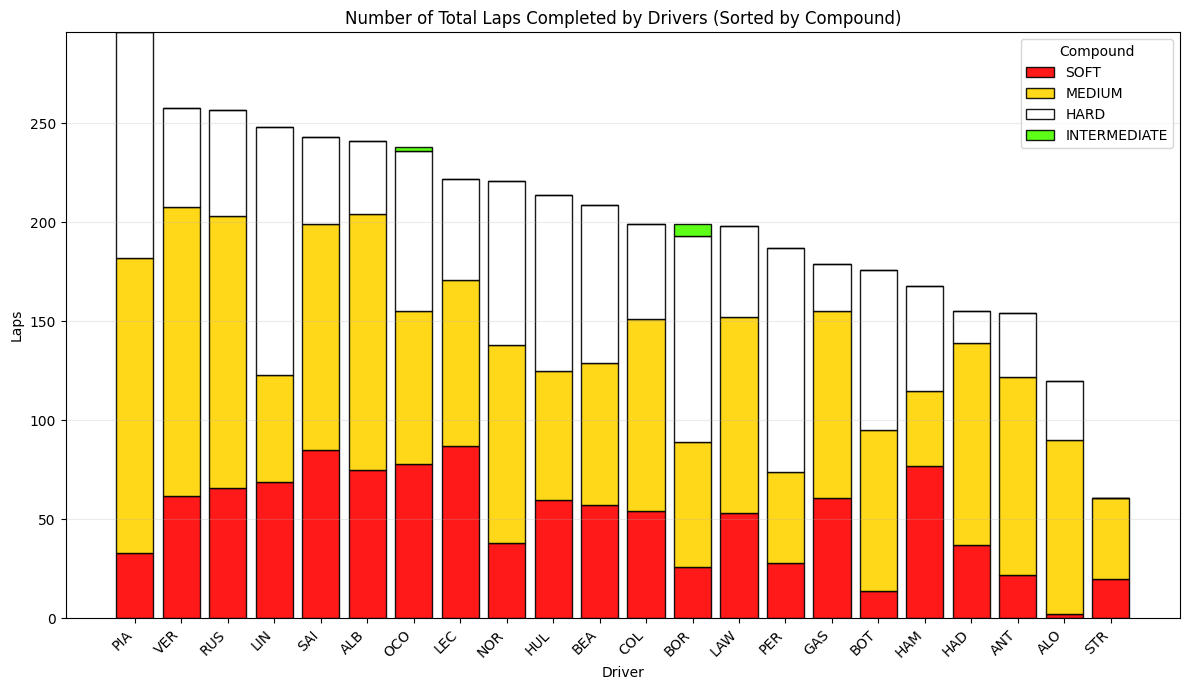

Laps completed by driver and compound (sorted):
Compound  SOFT  MEDIUM  HARD  INTERMEDIATE  TotalLaps
Driver                                               
PIA         33     149   114             0        296
VER         62     146    50             0        258
RUS         66     137    54             0        257
LIN         69      54   125             0        248
SAI         85     114    44             0        243
ALB         75     129    37             0        241
OCO         78      77    81             2        238
LEC         87      84    51             0        222
NOR         38     100    83             0        221
HUL         60      65    89             0        214
BEA         57      72    80             0        209
COL         54      97    48             0        199
BOR         26      63   104             6        199
LAW         53      99    46             0        198
PER         28      46   113             0        187
GAS         61      94    24      

In [8]:
# Laps completed per driver, sorted by dominant compound
if 'Compound' in df.columns:
    compound_counts = (df.dropna(subset=['Driver', 'Compound'])
                       .assign(Compound=lambda x: x['Compound'].astype(str).str.upper())
                       .groupby(['Driver', 'Compound']).size().unstack(fill_value=0)
                       )

    # Keep compounds in a meaningful racing order first, then any extras
    preferred_compound_order = [c for c in ['SOFT', 'MEDIUM', 'HARD', 'INTER', 'WET'] if c in compound_counts.columns]
    remaining_compounds = sorted([c for c in compound_counts.columns if c not in preferred_compound_order])
    compound_order = preferred_compound_order + remaining_compounds
    compound_counts = compound_counts.reindex(columns=compound_order, fill_value=0)

    dominant_compound = compound_counts.idxmax(axis=1)
    order_df = pd.DataFrame({'Driver': compound_counts.index,
                             'DominantCompound': pd.Categorical(dominant_compound, categories=compound_order, ordered=True),
                             'TotalLaps': compound_counts.sum(axis=1)}).reset_index(drop=True)

    # Sort by dominant compound, then by total laps (descending)
    driver_order = order_df.sort_values(['TotalLaps'],ascending=[False])['Driver']
    compound_counts = compound_counts.loc[driver_order]
    compound_counts_output = compound_counts.reset_index().rename(columns={'index': 'Driver'})

    plt.figure(figsize=(12, 7))
    fig = plt.gcf()
    bottom = np.zeros(len(compound_counts), dtype=float)

    for compound in compound_order:
        laps = compound_counts[compound].values
        plt.bar(compound_counts.index, laps, bottom=bottom, label=compound, color=tyre_palette.get(compound, '#CCCCCC'), edgecolor='black',alpha=0.9)
        bottom += laps

    plt.title('Number of Total Laps Completed by Drivers (Sorted by Compound)')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_laps_per_driver_compound.png")

    print('Laps completed by driver and compound (sorted):')
    print(compound_counts.assign(TotalLaps=compound_counts.sum(axis=1)).to_string())
else:
    # Fallback if compound data is unavailable
    laps_by_driver = df.groupby('Driver').size().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    fig = plt.gcf()
    colors = [driver_palette.get(driver, '#CCCCCC') for driver in laps_by_driver.index]
    plt.bar(laps_by_driver.index, laps_by_driver.values, color=colors, edgecolor='black', alpha=0.85)
    plt.title('Number of Total Laps Completed by Drivers')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_laps_per_driver.png")

    print('Laps completed by driver:')
    print(laps_by_driver.rename('Laps').to_string())

### Lap Time Trends by Session

Median lap-time traces by lap number show how pace evolves inside Day 1, Day 2, and Day 3. Spikes and troughs usually reflect changes in run intention rather than pure car performance, so the session view helps separate recurring pace behavior from one-off operational noise.

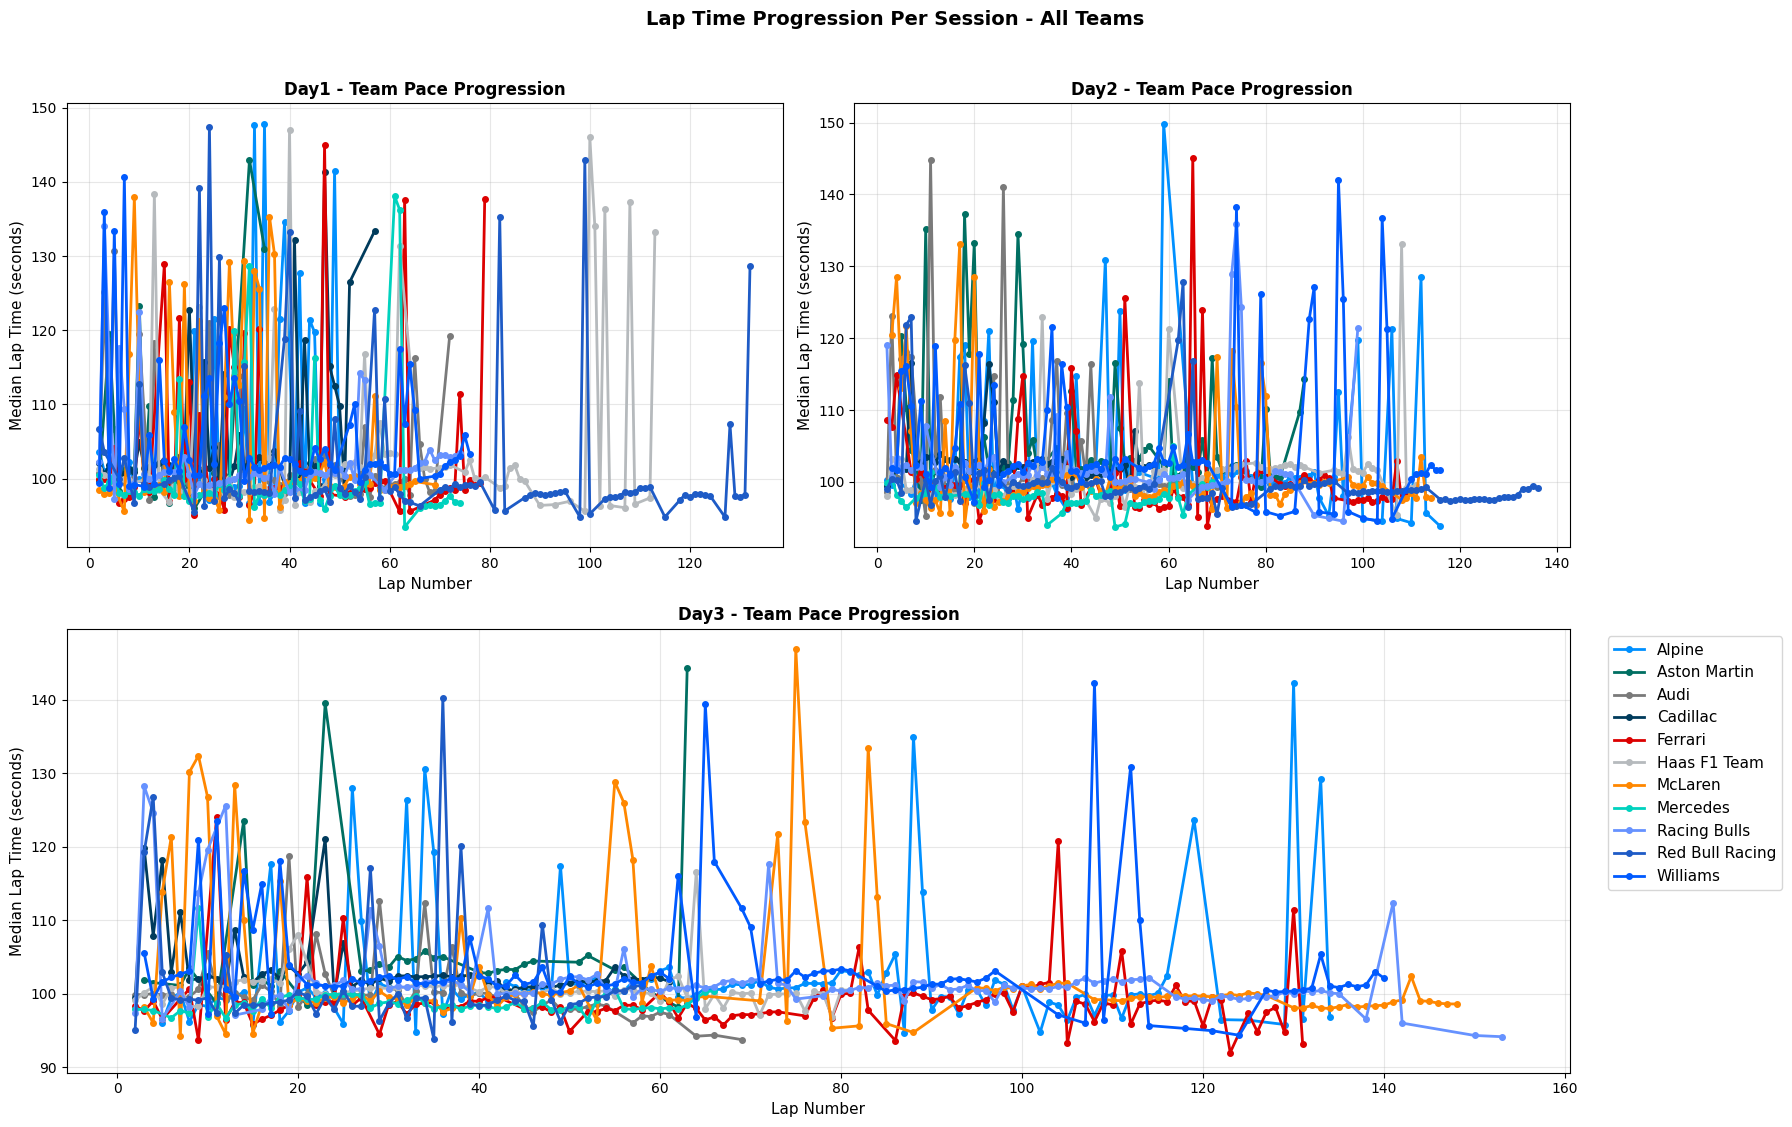

In [9]:
# Lap time progression by session and team (median pace by lap number)
layout = [['Day1', 'Day2'], ['Day3', 'Day3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty:
            continue
        trend = (team_session.groupby('LapNumber', as_index=False)['LapTime'].median().sort_values('LapNumber'))
        ax.plot(trend['LapNumber'], trend['LapTime'], marker='o', linewidth=2, markersize=4, label=team, color=team_palette.get(team, 'gray'))
        
    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Median Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Team Pace Progression', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Progression Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_lap_time_progression_by_session.png")

### Stint Pace Trends by Session

Averaging lap time by stint smooths some of the lap-to-lap volatility and makes each team's run structure easier to compare. These plots are best read as context-aware indicators: they combine tyre state, fuel load evolution, and execution quality rather than representing a pure ranking of intrinsic pace.

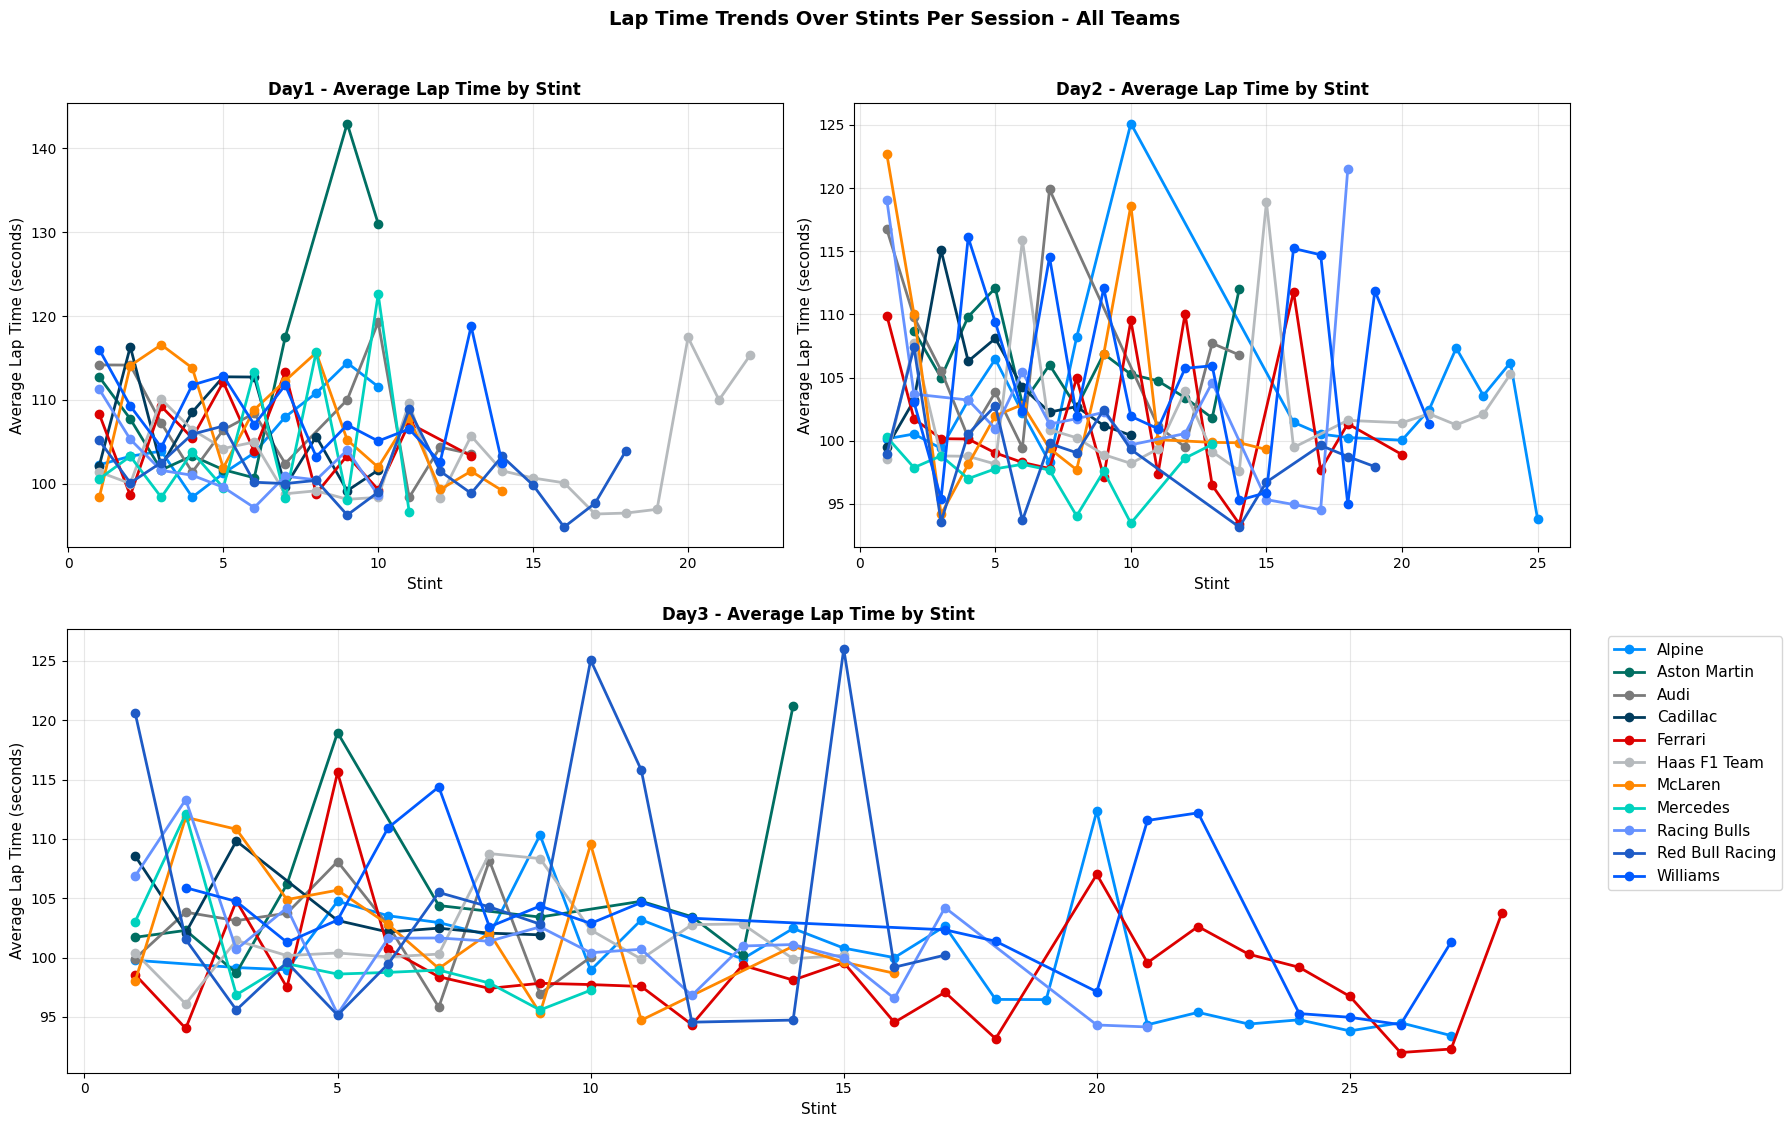

In [10]:
# Average lap time by stint for each session and team
layout = [['Day1', 'Day2'], ['Day3', 'Day3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'Stint' not in team_session.columns:
            continue
        team_session = team_session.dropna(subset=['Stint', 'LapTime'])
        if team_session.empty:
            continue
        stint_avg = (team_session.groupby('Stint', as_index=False)['LapTime'].mean().sort_values('Stint'))
        ax.plot(stint_avg['Stint'], stint_avg['LapTime'], marker='o', linewidth=2, markersize=6, color=team_palette.get(team, 'gray'), label=team)

    ax.set_xlabel('Stint', fontsize=11)
    ax.set_ylabel('Average Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Average Lap Time by Stint', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Trends Over Stints Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_stint_pace_trends.png")

### Speed Trap Trends by Session

Speed-trap traces add straight-line context to the lap-time story. Consistent top-end speed can indicate efficiency or deployment strength, but isolated slow points often come from traffic, lift-and-coast, pit-lane transitions, or non-push laps.

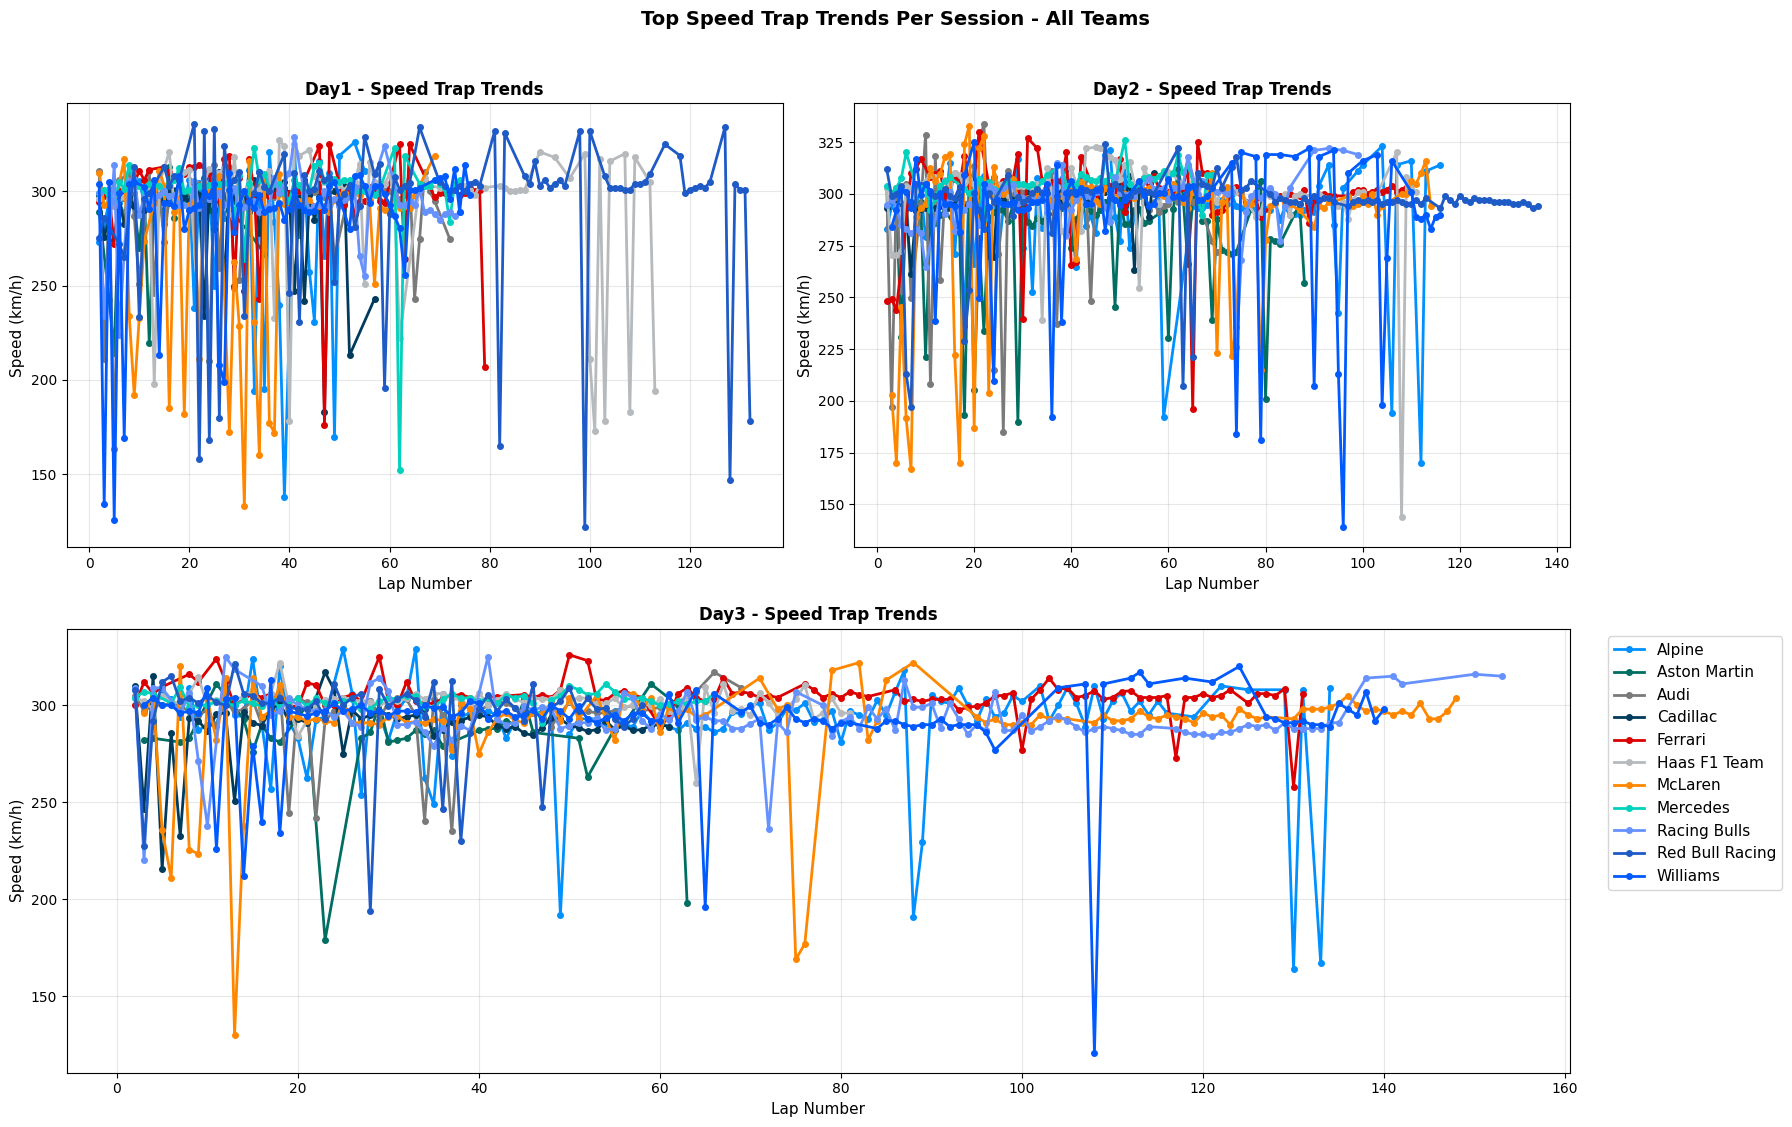

In [11]:
# Speed trap trends over sessions for all teams (median speed by lap number)
layout = [['Day1', 'Day2'], ['Day3', 'Day3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'SpeedST' not in team_session.columns:
            continue
        speed_trend = (team_session.dropna(subset=['SpeedST']).groupby('LapNumber', as_index=False)['SpeedST'].median().sort_values('LapNumber'))
        if speed_trend.empty:
            continue
        ax.plot(speed_trend['LapNumber'], speed_trend['SpeedST'], marker='o', linewidth=2, markersize=4, label=team,
                color=team_palette.get(team, 'gray'))

    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'{session_name} - Speed Trap Trends', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Top Speed Trap Trends Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_speed_trap_trends.png")

### Telemetry and Track Map

This section compares the fastest available telemetry traces for all teams and overlays speed on the circuit map. The code intentionally skips missing or unreliable telemetry so the notebook can still run cleanly when a session pull does not return a full set of valid laps.

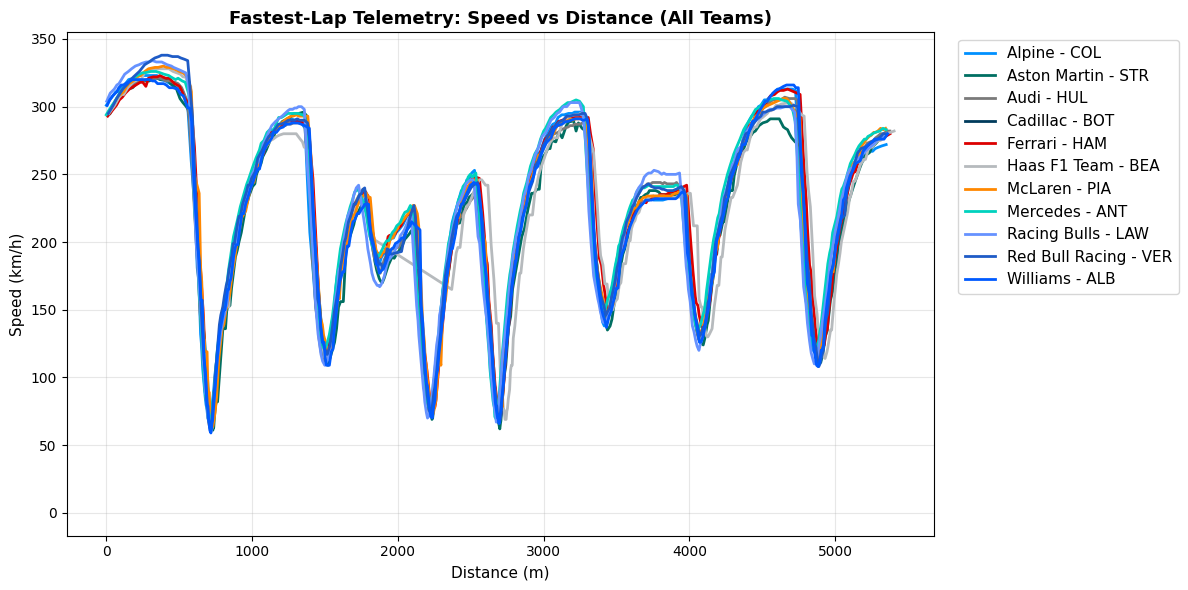

Telemetry fastest-lap summary:
           Team Driver Session  LapTimeSec
       Mercedes    ANT    Day3      93.669
        Ferrari    HAM    Day3      94.209
        McLaren    PIA    Day3      94.549
Red Bull Racing    VER    Day1      94.798
   Haas F1 Team    BEA    Day2      95.394
         Alpine    COL    Day3      95.806
           Audi    HUL    Day3      96.291
       Williams    ALB    Day3      96.793
   Racing Bulls    LAW    Day3      96.808
       Cadillac    BOT    Day2      96.824
   Aston Martin    STR    Day3      98.165


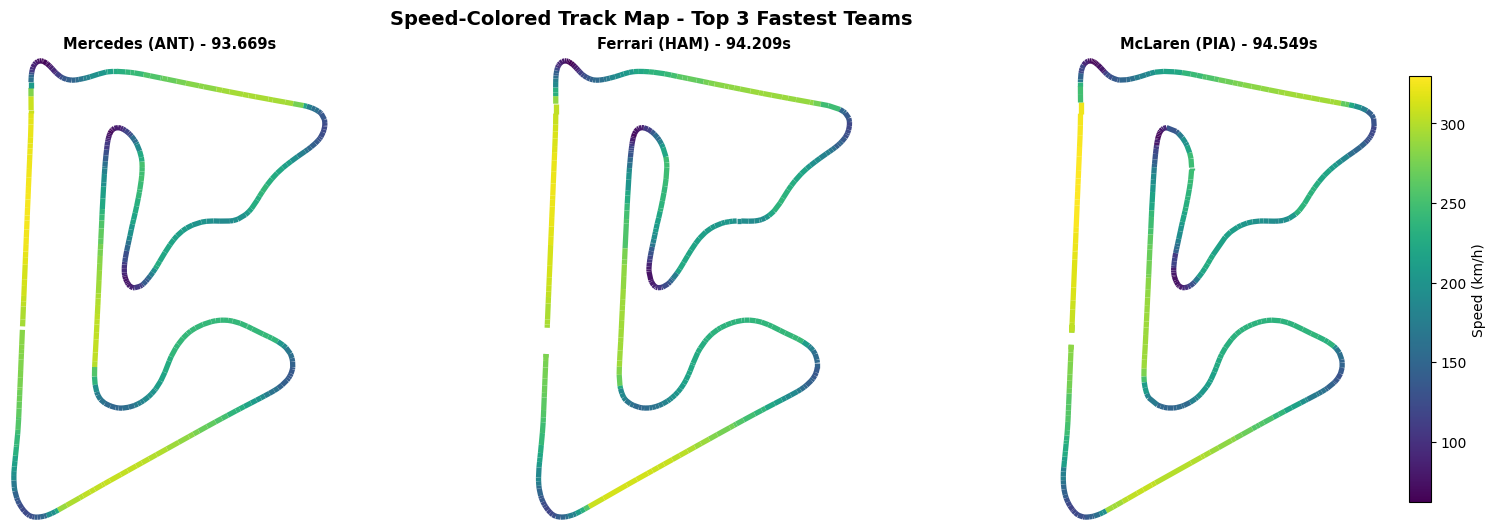

In [12]:
# Telemetry comparison and speed-colored track maps for fastest available laps
def lap_to_seconds(lap_time):
    return float(lap_time.total_seconds()) if pd.notna(lap_time) else np.nan

team_fastest = {}
for team in sorted(df['Team'].dropna().unique().tolist()):
    candidate_laps = []
    for session_name in session_names:
        session = sessions_by_name.get(session_name)
        if session is None:
            print(f"Session {session_name} not found in startup cache; skipping in telemetry block.")
            continue

        try:
            team_laps = session.laps.pick_teams(team).pick_quicklaps()
            if team_laps is None or len(team_laps) == 0:
                continue

            fastest = team_laps.pick_fastest()
            if fastest is not None and pd.notna(fastest['LapTime']):
                candidate_laps.append((session_name, fastest))
        except Exception as exc:
            print(f"Skipping {team} {session_name}: {exc}")

    if len(candidate_laps) == 0:
        print(f"No reliable telemetry lap found for {team} yet. Keeping logic for future reruns.")
        continue

    best_session, best_lap = min(candidate_laps, key=lambda item: item[1]['LapTime'])
    team_fastest[team] = {'session': best_session, 'lap': best_lap}

if len(team_fastest) == 0:
    print('No telemetry laps available to plot right now.')
else:
    # Speed vs distance telemetry traces
    fig, ax = plt.subplots(figsize=(12, 6))
    summary_rows = []

    for team, payload in team_fastest.items():
        lap = payload['lap']
        session_name = payload['session']
        try:
            telemetry = lap.get_car_data().add_distance()
            ax.plot(telemetry['Distance'], telemetry['Speed'], color=team_palette.get(team, 'gray'), linewidth=2, label=f"{team} - {lap['Driver']}")
            summary_rows.append({'Team': team, 'Driver': lap['Driver'], 'Session': session_name, 
                                 'LapTimeSec': lap_to_seconds(lap['LapTime'])
                                 })
        except Exception as exc:
            print(f"Telemetry plot skipped for {team}: {exc}")

    ax.set_title('Fastest-Lap Telemetry: Speed vs Distance (All Teams)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Distance (m)', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.grid(alpha=0.3)
    if summary_rows:
        ax.legend(fontsize=11, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_fastest_telemetry_speed_vs_distance.png")

    if summary_rows:
        telemetry_summary = pd.DataFrame(summary_rows).sort_values('LapTimeSec').reset_index(drop=True)
        print('Telemetry fastest-lap summary:')
        print(telemetry_summary.to_string(index=False))

    # Track map colored by speed for the 3 fastest teams in one row
    map_data = {}
    for team, payload in team_fastest.items():
        lap = payload['lap']
        try:
            car = lap.get_car_data()[['Time', 'Speed']].copy().sort_values('Time')
            pos = lap.get_pos_data()[['Time', 'X', 'Y']].copy().sort_values('Time')

            if car.empty or pos.empty:
                print(f"Track map skipped for {team}: empty telemetry frames")
                continue

            merged = pd.merge_asof(pos, car, on='Time', direction='nearest')
            merged = merged.dropna(subset=['X', 'Y', 'Speed'])
            if len(merged) < 2:
                print(f"Track map skipped for {team}: insufficient merged telemetry points")
                continue

            map_data[team] = {'x': merged['X'].to_numpy(), 'y': merged['Y'].to_numpy(), 'speed': merged['Speed'].to_numpy(), 'driver': lap['Driver'],
                              'lap_time_sec': lap_to_seconds(lap['LapTime'])
                              }
        except Exception as exc:
            print(f"Track map skipped for {team}: {exc}")

    if len(map_data) == 0:
        print('No track-map telemetry available to draw right now.')
    else:
        top_teams = sorted(map_data.keys(), key=lambda t: map_data[t]['lap_time_sec'])[:3]

        n_teams = len(top_teams)
        fig, axes = plt.subplots(1, n_teams, figsize=(5.6 * n_teams, 5.2), constrained_layout=True)
        axes_flat = np.atleast_1d(axes).ravel()

        global_speed_min = min(map_data[t]['speed'].min() for t in top_teams)
        global_speed_max = max(map_data[t]['speed'].max() for t in top_teams)
        norm = plt.Normalize(global_speed_min, global_speed_max)

        for idx, team in enumerate(top_teams):
            ax = axes_flat[idx]
            x = map_data[team]['x']
            y = map_data[team]['y']
            speed = map_data[team]['speed']
            driver = map_data[team]['driver']

            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap='viridis', norm=norm)
            lc.set_array(speed[:-1])
            lc.set_linewidth(3.8)

            ax.add_collection(lc)
            ax.set_aspect('equal', 'box')
            ax.set_xlim(x.min() - 100, x.max() + 100)
            ax.set_ylim(y.min() - 100, y.max() + 100)
            ax.axis('off')
            ax.set_title(f"{team} ({driver}) - {map_data[team]['lap_time_sec']:.3f}s", fontsize=10.5, fontweight='bold')

        sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes_flat, fraction=0.03, pad=0.02, shrink=0.92)
        cbar.set_label('Speed (km/h)')

        fig.suptitle('Speed-Colored Track Map - Top 3 Fastest Teams', fontsize=14, fontweight='bold')
        plt.show()
        save_figure(fig, f"f1_{year}_{cache_tag}_speed_colored_track_map.png")

### Tyre Compound Performance

Compound-level distributions show whether pace and consistency change when teams switch between SOFT, MEDIUM, and HARD tyres. Even when average lap time is similar, the spread can differ sharply because warm-up behavior, push-lap intent, and degradation profiles are not the same across compounds.

SOFT laps often contain both the strongest single-lap pace and some of the noisiest practice examples. That is why this notebook uses visual diagnostics and not just simple mean comparisons.

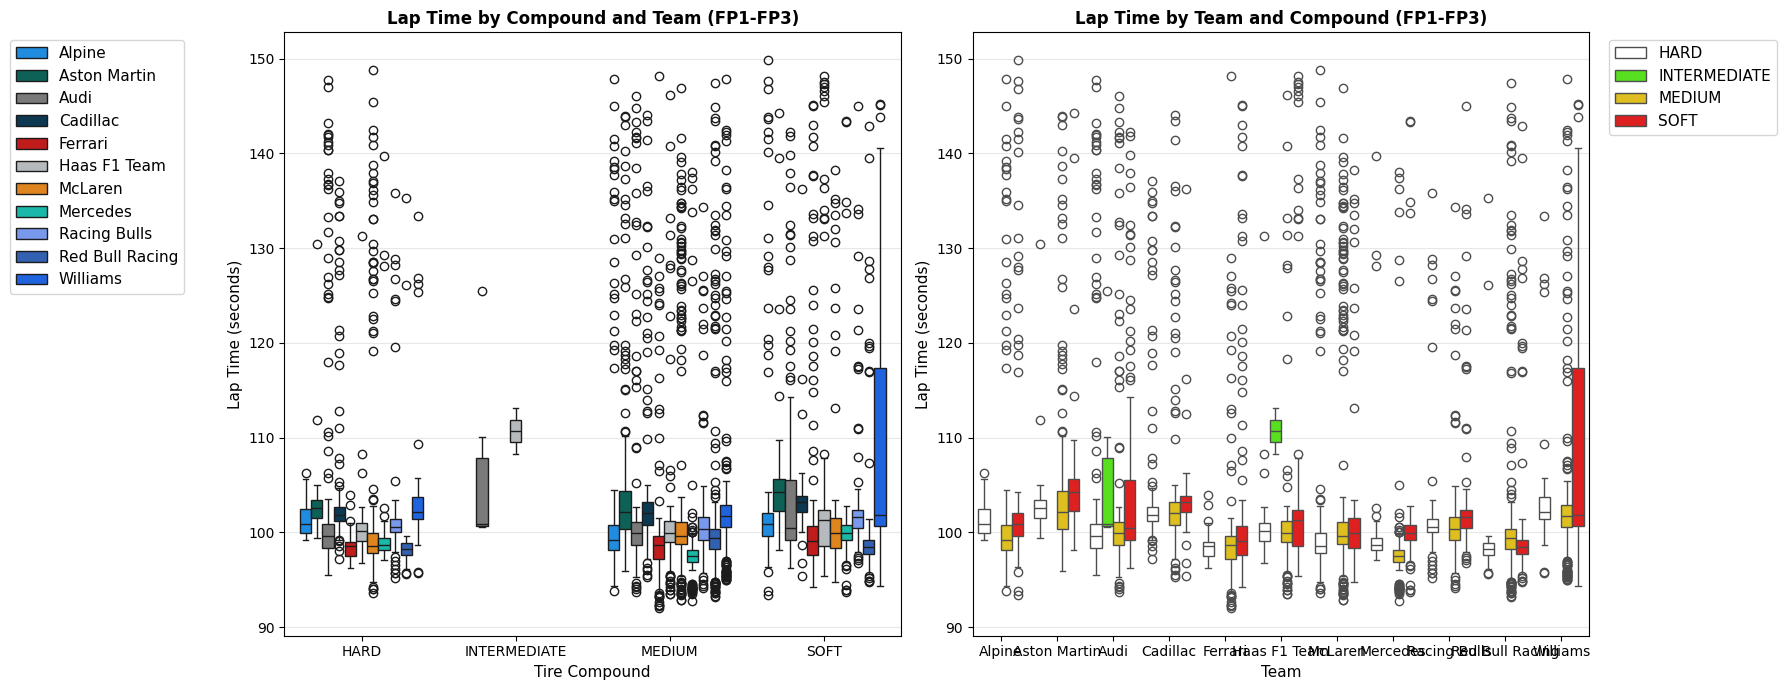

Average Lap Time by Team and Compound:
                                 mean     std  count
Team            Compound                            
Alpine          HARD          101.198   1.581     72
                MEDIUM        102.344  11.044    191
                SOFT          105.271  13.144    115
Aston Martin    HARD          103.697   5.469     30
                MEDIUM        106.158  11.206    129
                SOFT          108.081  12.264     22
Audi            HARD          103.935  12.385    193
                INTERMEDIATE  106.439  10.049      6
                MEDIUM        104.362  12.543    128
                SOFT          106.344  12.414     86
Cadillac        HARD          104.119   7.815    194
                MEDIUM        105.613  10.427    127
                SOFT          103.963   6.064     42
Ferrari         HARD           98.440   1.271    104
                MEDIUM        100.482   8.662    122
                SOFT          102.443  11.003    164
Haas F1

In [13]:
# Tyre compound performance across all teams
session_df = df[df['Session'].isin(session_names)].copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lap time by compound, segmented by team
compound_order = sorted([c for c in session_df['Compound'].dropna().unique()])
sns.boxplot(data=session_df[session_df['Compound'].notna()], x='Compound', y='LapTime', hue='Team', order=compound_order,
            hue_order=sorted(box_data['Team'].dropna().unique().tolist()), palette=team_palette, ax=axes[0]
            )

axes[0].set_xlabel('Tire Compound', fontsize=11)
axes[0].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[0].set_title('Lap Time by Compound and Team (FP1-FP3)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=11, ncol=1, bbox_to_anchor=(-0.15, 1), loc='upper right')

# Lap time by team, segmented by compound
team_order = sorted(session_df['Team'].dropna().unique().tolist())
sns.boxplot(data=session_df[session_df['Compound'].notna()], x='Team', y='LapTime', hue='Compound', order=team_order,
            hue_order=compound_order, palette={c: tyre_palette.get(c, 'gray') for c in compound_order}, ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time by Team and Compound (FP1-FP3)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
compound_performance_summary = (session_df[session_df['Compound'].notna()].groupby(['Team', 'Compound'])['LapTime'].agg(['mean', 'std', 'count'])
                                .reset_index())
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_compound_performance.png")

print('Average Lap Time by Team and Compound:')
print(session_df.groupby(['Team', 'Compound'])['LapTime'].agg(['mean', 'std', 'count']).round(3).sort_index())

### Tyre Compound Thermal Degradation

The correlation heatmap quantifies the linear relationship between TrackTemp, AirTemp, Humidity, TyreLife, and LapTime. A positive correlation between TrackTemp and LapTime would indicate that hotter conditions slow the car, consistent with increased tyre graining or blistering on the softer compounds. TyreLife is expected to show the strongest positive correlation with LapTime, as degradation is the dominant driver of lap time loss across a stint

The scatter plot overlays TyreLife against TrackTemp with LapTime encoded as colour. Clusters of dark points (slower laps) at high TyreLife and high TrackTemp would confirm that thermal stress compounds degradation beyond what tyre age alone explains — the interaction effect that motivated adding these features to the degradation model.

The per-compound bar charts bin TrackTemp into six equal-width bands and plot the median lap time within each band. A consistent upward trend across bands for SOFT tyres would suggest that the compound is more thermally sensitive than MEDIUM or HARD, which is expected given its lower glass transition temperature and thinner tread gauge. Flat or non-monotonic trends would indicate that thermal variance at this circuit is within the compound's operating window and contributes little predictive value to the model.

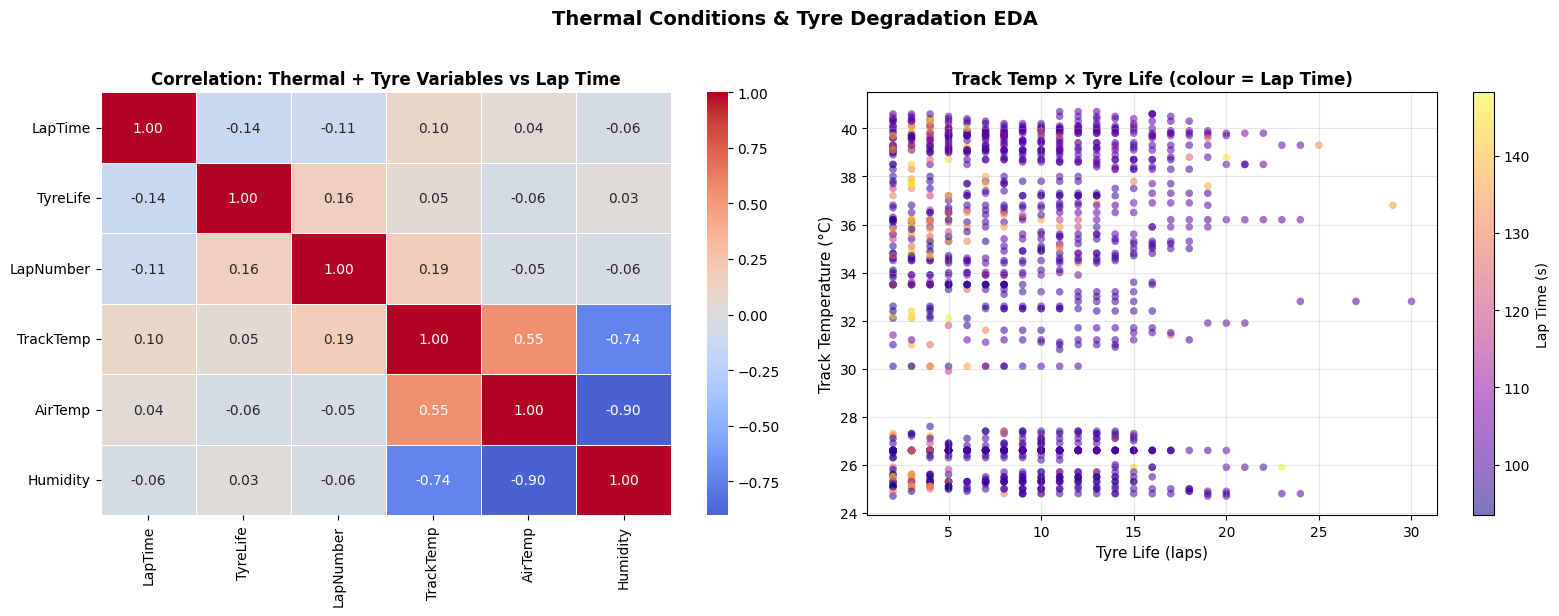

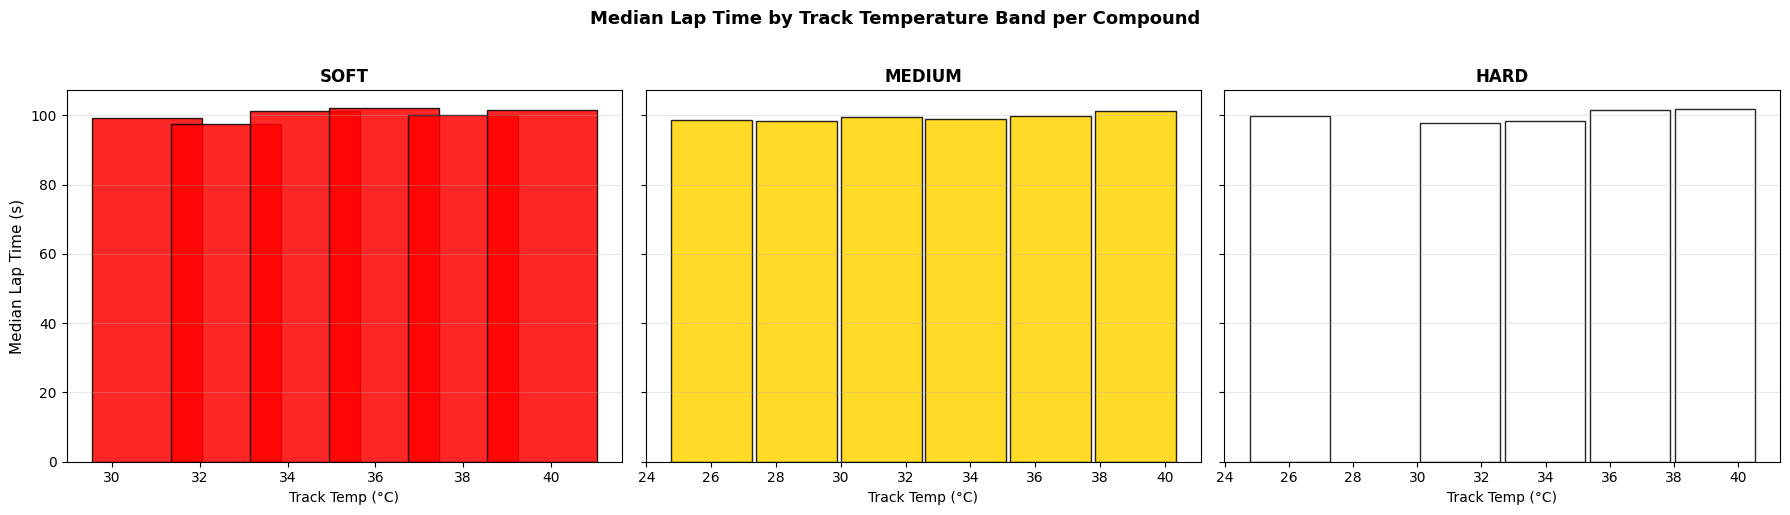

Thermal correlation with LapTime:
TrackTemp    0.104
AirTemp      0.044
Humidity    -0.059


In [14]:
# Thermal & Tyre Degradation EDA
thermal_cols_present = [c for c in ['TrackTemp', 'AirTemp', 'Humidity']
                        if c in df.columns and df[c].notna().any()]

COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

if thermal_cols_present:
    deg_eda_df = (df[df['Compound'].isin(COMPOUNDS) &
                              df['LapTime'].notna() &
                              df['TyreLife'].notna()]
                  .copy())

    # Correlation heatmap: thermal + tyre inputs vs lap time
    corr_cols = ['LapTime', 'TyreLife', 'LapNumber'] + thermal_cols_present
    corr_matrix = deg_eda_df[corr_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=axes[0])
    axes[0].set_title('Correlation: Thermal + Tyre Variables vs Lap Time',
                      fontsize=12, fontweight='bold')

    # TrackTemp × TyreLife scatter coloured by LapTime per compound
    scatter_df = deg_eda_df.dropna(subset=['TrackTemp'] + ['LapTime', 'TyreLife'])
    sc = axes[1].scatter(scatter_df['TyreLife'], scatter_df['TrackTemp'],
                         c=scatter_df['LapTime'], cmap='plasma',
                         alpha=0.55, s=30, edgecolors='none')
    plt.colorbar(sc, ax=axes[1], label='Lap Time (s)')
    axes[1].set_xlabel('Tyre Life (laps)', fontsize=11)
    axes[1].set_ylabel('Track Temperature (°C)', fontsize=11)
    axes[1].set_title('Track Temp × Tyre Life (colour = Lap Time)',
                      fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.suptitle('Thermal Conditions & Tyre Degradation EDA',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_thermal_degradation_eda.png")

    # Per-compound: median lap time binned by TrackTemp
    fig, axes = plt.subplots(1, len(COMPOUNDS), figsize=(18, 5), sharey=True)
    for idx, compound in enumerate(COMPOUNDS):
        comp_df = deg_eda_df[deg_eda_df['Compound'] == compound].dropna(subset=['TrackTemp'])
        if comp_df.empty:
            axes[idx].set_visible(False)
            continue
        comp_df['TempBin'] = pd.cut(comp_df['TrackTemp'], bins=6)
        binned = comp_df.groupby('TempBin', observed=True)['LapTime'].median().reset_index()
        binned['TempMid'] = binned['TempBin'].apply(lambda x: x.mid)
        axes[idx].bar(binned['TempMid'].astype(float), binned['LapTime'],
                      width=2.5, color=tyre_palette.get(compound, 'gray'),
                      edgecolor='black', alpha=0.85)
        axes[idx].set_title(f'{compound}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Track Temp (°C)', fontsize=10)
        axes[idx].grid(alpha=0.3, axis='y')

    axes[0].set_ylabel('Median Lap Time (s)', fontsize=11)
    plt.suptitle('Median Lap Time by Track Temperature Band per Compound',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_laptime_by_tracktemp_compound.png")

    print("Thermal correlation with LapTime:")
    print(corr_matrix['LapTime'][thermal_cols_present].round(3).to_string())
else:
    print("No thermal columns available in df — skipping thermal EDA.")

## Machine Learning Analysis

This section builds supervised regression models to predict all-team lap time from lap context, tyre state, straight-line speed, and driver-team identifiers. Performance is evaluated with a baseline benchmark plus MAE, RMSE, and R2 on a held-out test split.

### Benchmark Model Pipeline

The pipeline keeps preprocessing and model fitting in one reproducible object. Numeric features are passed through directly, categorical variables are one-hot encoded, and ensemble regressors are trained on a filtered benchmark-oriented subset of the practice data.

The current implementation focuses the training set on SOFT-tyre laps marked as fresh-tyre runs before fitting the models.

In [15]:
def benchmark_model_pipeline():
    print("Starting benchmark model pipeline")

    # Use all-team data and keep columns needed for modeling
    model_df = df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")

    # Define features and target (add telemetry/sector signals when available)
    base_num_features = ['LapNumber', 'TyreLife', 'Stint', 'Test']
    base_cat_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    telemetry_candidate_features = ['SpeedST','SpeedI1', 'SpeedI2', 'SpeedFL', 'Throttle', 'Brake', 'DRS']

    numeric_features = [col for col in base_num_features if col in model_df.columns]
    telemetry_features = [
        col for col in telemetry_candidate_features
        if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
    ]
    numeric_features = numeric_features + telemetry_features
    categorical_features = [col for col in base_cat_features if col in model_df.columns]
    features = numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = features + [target]
    model_df = model_df[required_cols].dropna().copy()

    # Split into features and target
    X = model_df[features].copy()
    y = model_df[target].copy()

    # One-hot encode categorical features
    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    print("Preprocessing pipeline created")

    # Use stratification only when every session has enough examples
    stratify_series = None
    session_counts = X['Session'].value_counts()
    if len(session_counts) > 1 and session_counts.min() >= 2:
        stratify_series = X['Session']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324, stratify=stratify_series)

    # F1-naive baseline suite for validation context
    train_df = X_train.copy()
    train_df['LapTime'] = y_train.values
    test_df = X_test.copy().reset_index(drop=True)

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    session_order = {'FP1': 1, 'FP2': 2, 'FP3': 3, 'Q': 4}
    train_df['SessionOrder'] = train_df['Session'].map(session_order).fillna(0)
    test_df['SessionOrder'] = test_df['Session'].map(session_order).fillna(0)

    # Create model pipelines
    rf_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('rf_regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=324))
               ])

    gb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('gb_regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=324))
               ])

    xgb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('xgb_regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=324, verbosity=0))
               ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Team-level diagnostics: choose the best model per team, not only globally.
    team_eval_df = X_test[['Team', 'Session']].copy().reset_index(drop=True)
    team_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    team_eval_df['RF_Pred'] = rf_predictions
    team_eval_df['GB_Pred'] = gb_predictions
    team_eval_df['XGB_Pred'] = xgb_predictions
    team_eval_df['RF_AbsErr'] = (team_eval_df['ActualLapTime'] - team_eval_df['RF_Pred']).abs()
    team_eval_df['GB_AbsErr'] = (team_eval_df['ActualLapTime'] - team_eval_df['GB_Pred']).abs()
    team_eval_df['XGB_AbsErr'] = (team_eval_df['ActualLapTime'] - team_eval_df['XGB_Pred']).abs()

    b_team_mae = (team_eval_df.groupby('Team', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr']].mean()
                  .rename(columns={
                      'RF_AbsErr': 'RF_MAE',
                      'GB_AbsErr': 'GB_MAE',
                      'XGB_AbsErr': 'XGB_MAE'
                      }))

    b_team_mae['BestModel'] = b_team_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].idxmin(axis=1).map({
        'RF_MAE': 'Random Forest Regression',
        'GB_MAE': 'Gradient Boosting Regression',
        'XGB_MAE': 'XGBoost Regression'
    })
    b_team_mae['BestMAE'] = b_team_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].min(axis=1)
    b_team_mae = b_team_mae.sort_values('BestMAE').reset_index(drop=True)

    print("Model training completed")

    return {
        'b_model_df': model_df,
        'b_features': features,
        'b_X_train': X_train,
        'b_X_test': X_test,
        'b_y_train': y_train,
        'b_y_test': y_test,
        'b_mean_baseline_mae': mean_baseline_mae,
        'b_mean_baseline_rmse': mean_baseline_rmse,
        'b_mean_baseline_r2': mean_baseline_r2,
        'b_rf_model': rf_model,
        'b_rf_predictions': rf_predictions,
        'b_rf_mae': rf_mae,
        'b_rf_rmse': rf_rmse,
        'b_rf_r2': rf_r2,
        'b_gb_model': gb_model,
        'b_gb_predictions': gb_predictions,
        'b_gb_mae': gb_mae,
        'b_gb_rmse': gb_rmse,
        'b_gb_r2': gb_r2,
        'b_xgb_model': xgb_model,
        'b_xgb_predictions': xgb_predictions,
        'b_xgb_mae': xgb_mae,
        'b_xgb_rmse': xgb_rmse,
        'b_xgb_r2': xgb_r2,
        'b_team_eval_df': team_eval_df,
        'b_team_mae': b_team_mae
    }

In [16]:
# Run the model pipeline
model_results = benchmark_model_pipeline()

# Extract results
b_model_df = model_results['b_model_df']
b_features = model_results['b_features']
b_X_train = model_results['b_X_train']
b_X_test = model_results['b_X_test']
b_y_train = model_results['b_y_train']
b_y_test = model_results['b_y_test']
b_mean_baseline_mae = model_results['b_mean_baseline_mae']
b_mean_baseline_rmse = model_results['b_mean_baseline_rmse']
b_mean_baseline_r2 = model_results['b_mean_baseline_r2']
b_rf_model = model_results['b_rf_model']
b_rf_predictions = model_results['b_rf_predictions']
b_rf_mae = model_results['b_rf_mae']
b_rf_rmse = model_results['b_rf_rmse']
b_rf_r2 = model_results['b_rf_r2']
b_gb_model = model_results['b_gb_model']
b_gb_predictions = model_results['b_gb_predictions']
b_gb_mae = model_results['b_gb_mae']
b_gb_rmse = model_results['b_gb_rmse']
b_gb_r2 = model_results['b_gb_r2']
b_xgb_model = model_results['b_xgb_model']
b_xgb_predictions = model_results['b_xgb_predictions']
b_xgb_mae = model_results['b_xgb_mae']
b_xgb_rmse = model_results['b_xgb_rmse']
b_xgb_r2 = model_results['b_xgb_r2']
b_team_eval_df = model_results['b_team_eval_df']
b_team_mae = model_results['b_team_mae']

Starting benchmark model pipeline
Preprocessing pipeline created
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [17]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline','Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [b_mean_baseline_mae, b_rf_mae, b_gb_mae, b_xgb_mae],
    'Root Absolute Error (RMSE)': [b_mean_baseline_rmse, b_rf_rmse, b_gb_rmse, b_xgb_rmse],
    'R² Score': [b_mean_baseline_r2, b_rf_r2, b_gb_r2, b_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Qualifying Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Team-level model selection now uses the fastest predicted lap across the 3 models.
print("\nTeam-level model picked by fastest predicted lap (lower seconds is better):")
print(b_team_mae[['Team', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'BestModel', 'BestMAE']].sort_values('BestMAE').to_string(index=False))

Qualifying Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                 3.312 sec                  5.974 sec   -0.000
    Random Forest Regression                 0.832 sec                  1.523 sec    0.935
Gradient Boosting Regression                 0.962 sec                  1.587 sec    0.929
          XGBoost Regression                 0.814 sec                  1.559 sec    0.932

Team-level model picked by fastest predicted lap (lower seconds is better):
           Team   RF_MAE   GB_MAE  XGB_MAE                BestModel  BestMAE
   Racing Bulls 0.473397 0.560663 0.469041       XGBoost Regression 0.469041
Red Bull Racing 0.515039 0.697484 0.594029 Random Forest Regression 0.515039
       Mercedes 0.683265 0.795843 0.644463       XGBoost Regression 0.644463
   Haas F1 Team 0.659621 0.844432 0.681630 Random Forest Regression 0.659621
         Alpine 0.791186 0.893442 0.702455   

#### Benchmark Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

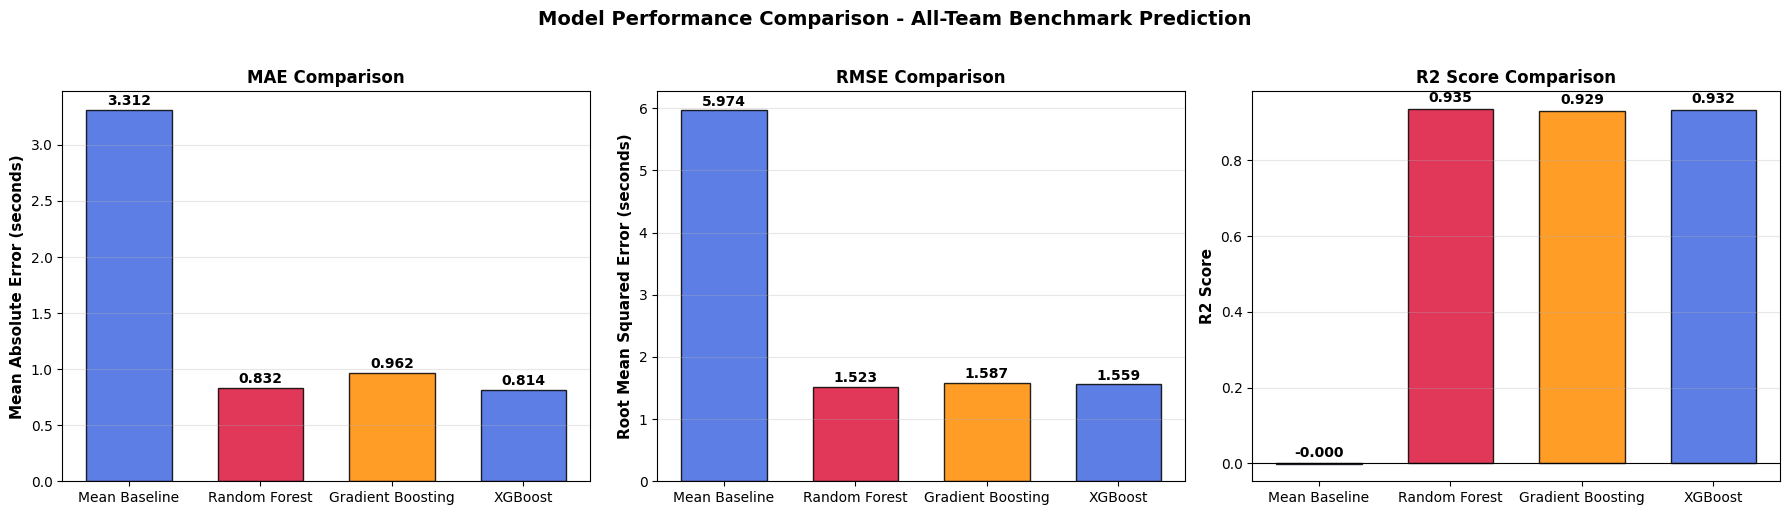

In [18]:
# Model comparison for all-team lap time prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [b_mean_baseline_mae, b_rf_mae, b_gb_mae, b_xgb_mae]
rmse_scores = [b_mean_baseline_rmse, b_rf_rmse, b_gb_rmse, b_xgb_rmse]
r2_scores = [b_mean_baseline_r2, b_rf_r2, b_gb_r2, b_xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ['royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison
axes[2].bar(models, r2_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - All-Team Benchmark Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_benchmark_model_comparison.png")

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

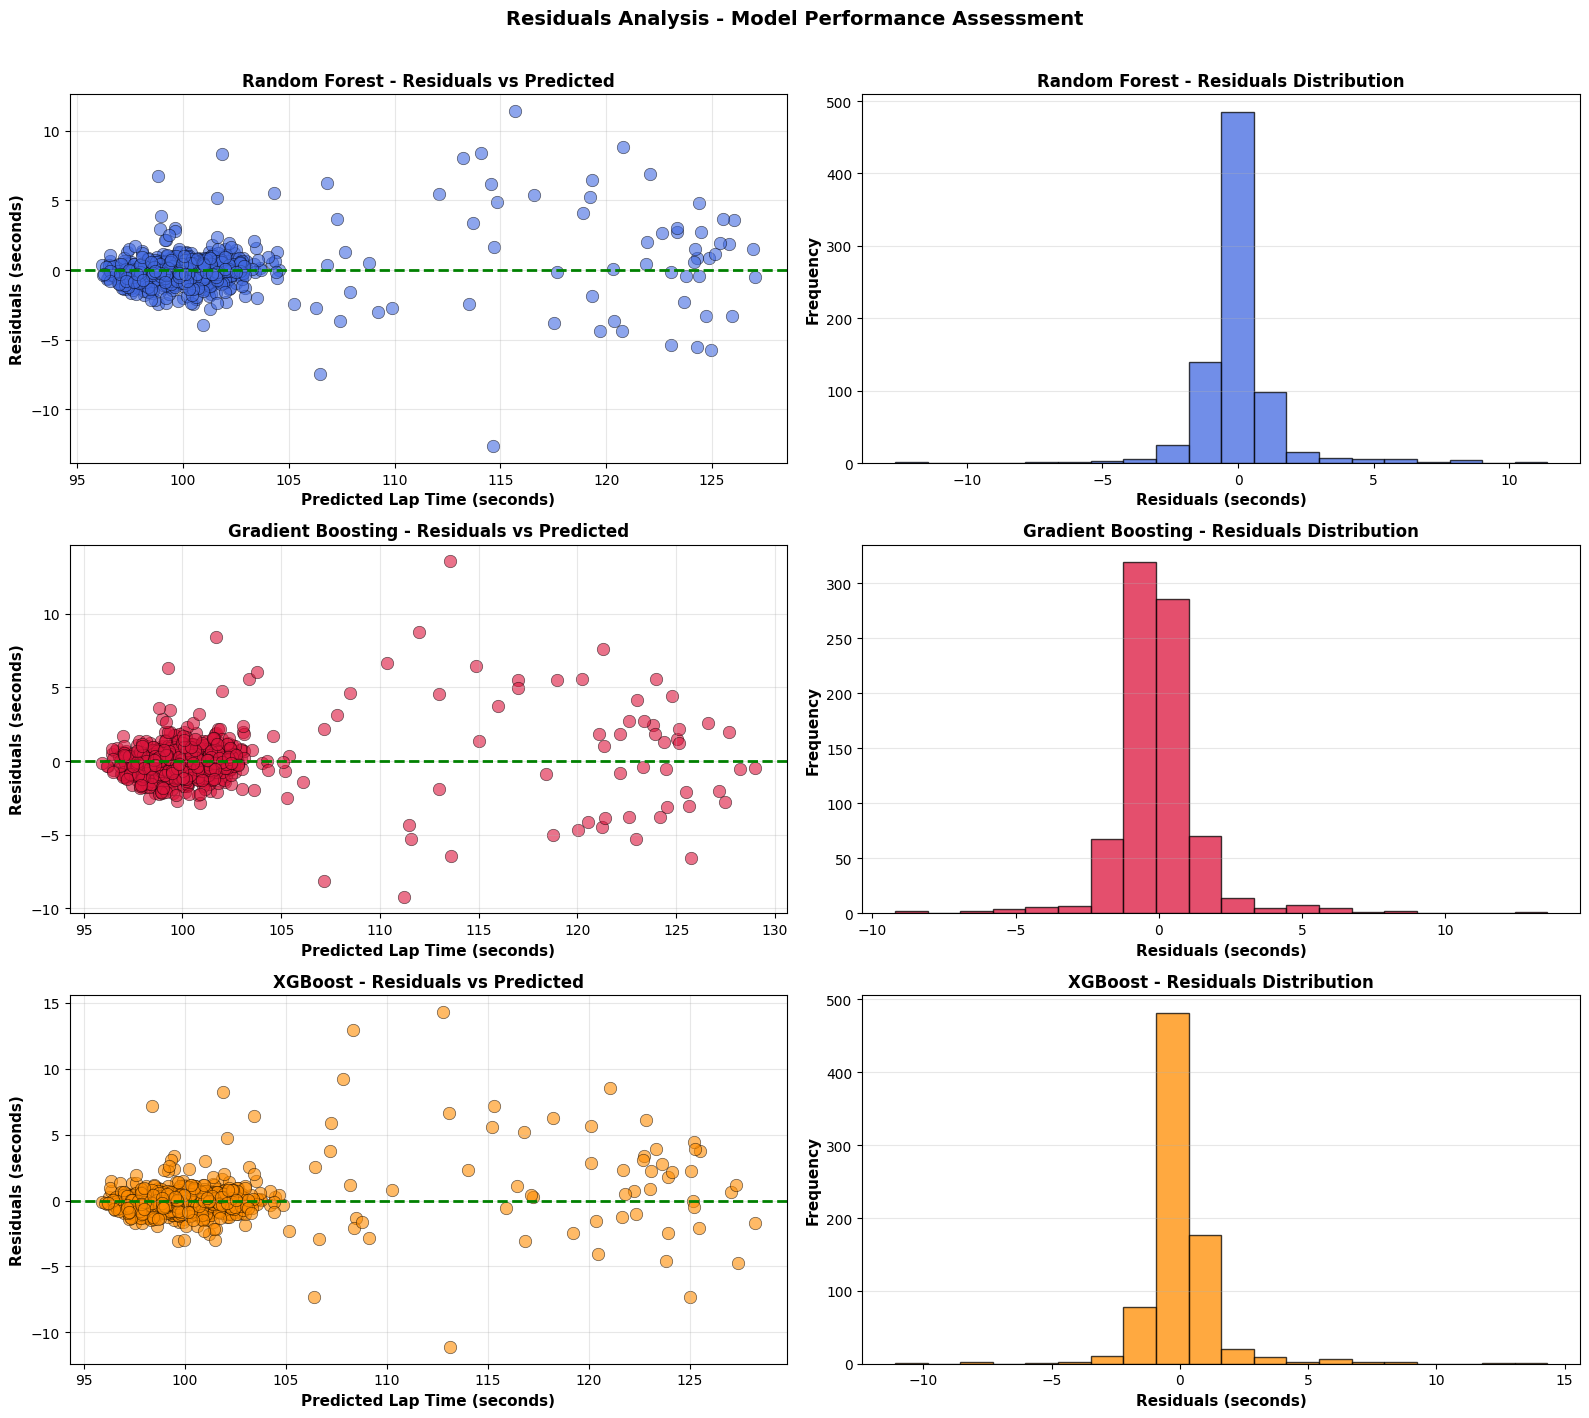

Random Forest - Mean Residuals: -0.0148, Std Dev: 1.5240
Gradient Boosting - Mean Residuals: -0.0104, Std Dev: 1.5884
XGBoost - Mean Residuals: 0.0579, Std Dev: 1.5584


In [19]:
# Residuals Analysis
rf_residuals = b_y_test - b_rf_predictions
gb_residuals = b_y_test - b_gb_predictions
xgb_residuals = b_y_test - b_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(b_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(b_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(b_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

C:\Users\nihaa_hjoailx\AppData\Local\Temp\ipykernel_13548\1929062083.py:44: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


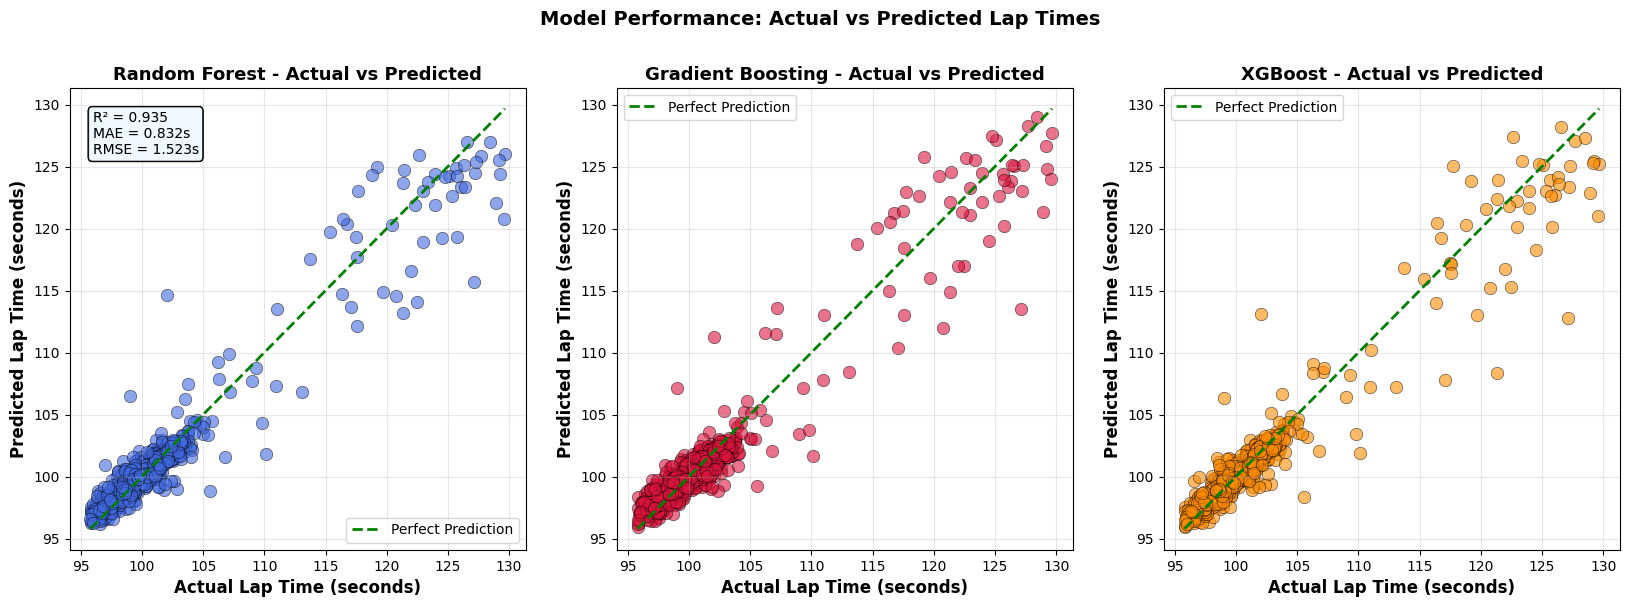

In [20]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(b_y_test, b_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {b_rf_r2:.3f}\nMAE = {b_rf_mae:.3f}s\nRMSE = {b_rf_rmse:.3f}s',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(b_y_test, b_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {b_rf_r2:.3f}\nMAE = {b_rf_mae:.3f}s\nRMSE = {b_rf_rmse:.3f}s',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# XGBoost: Actual vs Predicted
axes[2].scatter(b_y_test, b_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, 0.95, f'R² = {b_rf_r2:.3f}\nMAE = {b_rf_mae:.3f}s\nRMSE = {b_rf_rmse:.3f}s',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Tyre Degradation Model Pipeline

In [21]:
def tyredeg_model_pipeline():
    print("Starting tyre degradation model pipeline")

    model_df = df.copy()

    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    required_filter_cols = ['Compound', 'TyreLife']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    compound_mask = model_df['Compound'].astype(str).str.upper().isin(valid_compounds)
    model_df = model_df[compound_mask].copy()
    print(f"Rows after compound filter (SOFT, MEDIUM, HARD): {len(model_df)}")
    print("Compound distribution:")
    print(model_df['Compound'].value_counts().to_string())

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")
    print("Session distribution:")
    print(model_df['Session'].value_counts().to_string())

    for numeric_col in ['LapNumber', 'TyreLife', 'Stint', 'SpeedST']:
        if numeric_col in model_df.columns:
            model_df[numeric_col] = pd.to_numeric(model_df[numeric_col], errors='coerce')

    session_order_map = {'Day1': 1, 'Day2': 2, 'Day3': 3}
    model_df['SessionOrder'] = model_df['Session'].map(session_order_map).fillna(0).astype(float)

    if 'FreshTyre' in model_df.columns:
        model_df['FreshTyre'] = model_df['FreshTyre'].fillna('Unknown').astype(str)

    model_df['TyreLife_sq'] = model_df['TyreLife'] ** 2
    model_df['TyreLife_cu'] = model_df['TyreLife'] ** 3
    model_df['TyreLife_log'] = np.log1p(model_df['TyreLife'].clip(lower=0))
    model_df['LapNumber_x_TyreLife'] = model_df['LapNumber'] * model_df['TyreLife']
    model_df['TyreLife_x_Stint'] = model_df['TyreLife'] * model_df['Stint']
    model_df['TyreLife_x_SessionOrder'] = model_df['TyreLife'] * model_df['SessionOrder']

    compound_upper = model_df['Compound'].astype(str).str.upper()
    compound_interaction_features = []
    for compound in valid_compounds:
        compound_mask = (compound_upper == compound).astype(float)
        model_df[f'TyreLife_x_{compound}'] = model_df['TyreLife'] * compound_mask
        model_df[f'TyreLife_sq_x_{compound}'] = model_df['TyreLife_sq'] * compound_mask
        compound_interaction_features.extend([f'TyreLife_x_{compound}', f'TyreLife_sq_x_{compound}'])

    base_numeric_features = ['LapNumber', 'TyreLife', 'Stint', 'SpeedST',
                            'SessionOrder', 'TyreLife_sq', 'TyreLife_cu', 'TyreLife_log',
                            'LapNumber_x_TyreLife', 'TyreLife_x_Stint', 'TyreLife_x_SessionOrder','Test'
                            ] + compound_interaction_features

    categorical_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    if 'FreshTyre' in model_df.columns:
        categorical_features.append('FreshTyre')

    features = base_numeric_features + categorical_features
    target = 'LapTime'

    required_cols = base_numeric_features + categorical_features + [target]
    model_df = model_df[required_cols].dropna().copy()

    print(f"TyreLife range: {model_df['TyreLife'].min()} to {model_df['TyreLife'].max()}")

    X = model_df[base_numeric_features + categorical_features].copy()
    y = model_df[target].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=324)
    train_idx, test_idx = next(splitter.split(X, y, groups=X['Driver']))
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', base_numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[base_numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[base_numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    rf_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf_regressor', RandomForestRegressor(n_estimators=420, min_samples_leaf=1, max_features='sqrt', random_state=324, n_jobs=-1))
    ])

    gb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('gb_regressor', GradientBoostingRegressor(n_estimators=350, learning_rate=0.04, subsample=0.85, random_state=324))
    ])

    xgb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('xgb_regressor', XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=4, min_child_weight=3, subsample=0.9, colsample_bytree=0.9, reg_alpha=0.1, reg_lambda=1.2, random_state=324, verbosity=0, objective='reg:squarederror', tree_method='hist'))
    ])

    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    t_driver_mae = (driver_eval_df.groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr']].mean()
                    .rename(columns={
                        'RF_AbsErr': 'RF_MAE',
                        'GB_AbsErr': 'GB_MAE',
                        'XGB_AbsErr': 'XGB_MAE'
                        }))

    t_driver_mae['BestModel'] = t_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].idxmin(axis=1).map({
        'RF_MAE': 'Random Forest Regression',
        'GB_MAE': 'Gradient Boosting Regression',
        'XGB_MAE': 'XGBoost Regression'
    })
    t_driver_mae['BestMAE'] = t_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].min(axis=1)
    t_driver_mae = t_driver_mae.sort_values('BestMAE').reset_index(drop=True)

    print("Model training completed")

    return {
        't_model_df': model_df,
        't_features': features,
        't_X_train': X_train,
        't_X_test': X_test,
        't_y_train': y_train,
        't_y_test': y_test,
        't_mean_baseline_predictions': mean_baseline_predictions,
        't_mean_baseline_mae': mean_baseline_mae,
        't_mean_baseline_rmse': mean_baseline_rmse,
        't_mean_baseline_r2': mean_baseline_r2,
        't_rf_model': rf_model,
        't_rf_predictions': rf_predictions,
        't_rf_mae': rf_mae,
        't_rf_rmse': rf_rmse,
        't_rf_r2': rf_r2,
        't_gb_model': gb_model,
        't_gb_predictions': gb_predictions,
        't_gb_mae': gb_mae,
        't_gb_rmse': gb_rmse,
        't_gb_r2': gb_r2,
        't_xgb_model': xgb_model,
        't_xgb_predictions': xgb_predictions,
        't_xgb_mae': xgb_mae,
        't_xgb_rmse': xgb_rmse,
        't_xgb_r2': xgb_r2,
        't_driver_eval_df': driver_eval_df,
        't_driver_mae': t_driver_mae
    }

In [22]:
# Run the model pipeline
model_results = tyredeg_model_pipeline()

# Extract results
t_model_df = model_results['t_model_df']
t_features = model_results['t_features']
t_X_train = model_results['t_X_train']
t_X_test = model_results['t_X_test']
t_y_train = model_results['t_y_train']
t_y_test = model_results['t_y_test']
t_mean_baseline_predictions = model_results['t_mean_baseline_predictions']
t_mean_baseline_mae = model_results['t_mean_baseline_mae']
t_mean_baseline_rmse = model_results['t_mean_baseline_rmse']
t_mean_baseline_r2 = model_results['t_mean_baseline_r2']
t_rf_model = model_results['t_rf_model']
t_rf_predictions = model_results['t_rf_predictions']
t_rf_mae = model_results['t_rf_mae']
t_rf_rmse = model_results['t_rf_rmse']
t_rf_r2 = model_results['t_rf_r2']
t_gb_model = model_results['t_gb_model']
t_gb_predictions = model_results['t_gb_predictions']
t_gb_mae = model_results['t_gb_mae']
t_gb_rmse = model_results['t_gb_rmse']
t_gb_r2 = model_results['t_gb_r2']
t_xgb_model = model_results['t_xgb_model']
t_xgb_predictions = model_results['t_xgb_predictions']
t_xgb_mae = model_results['t_xgb_mae']
t_xgb_rmse = model_results['t_xgb_rmse']
t_xgb_r2 = model_results['t_xgb_r2']
t_driver_mae = model_results['t_driver_mae']

Starting tyre degradation model pipeline
Rows after compound filter (SOFT, MEDIUM, HARD): 3989
Compound distribution:
Compound
MEDIUM    1719
HARD      1288
SOFT       982
Session distribution:
Session
Day3    1519
Day2    1329
Day1    1141
TyreLife range: 2.0 to 35.0
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [23]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline', 'Random Forest Regression', 'Gradient Boosting Regression', 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae],
    'Root Absolute Error (RMSE)': [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse],
    'R² Score': [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best tyre degradation model.
if t_rf_r2 > t_gb_r2 and t_rf_r2 > t_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_rf_r2 < t_gb_r2 and t_gb_r2 > t_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_xgb_r2 > t_rf_r2 and t_xgb_r2 > t_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
else:
    print("\nModels have the same R² score. No clear best model.")

# Driver-level model selection now uses the fastest predicted lap across the 3 models.
print("\nTeam-level model comparison:")
print(b_team_mae[['Team', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'BestModel', 'BestMAE']].sort_values('BestMAE').to_string(index=False))

Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                 3.074 sec                  5.880 sec   -0.000
    Random Forest Regression                 2.462 sec                  4.511 sec    0.411
Gradient Boosting Regression                 2.207 sec                  4.292 sec    0.467
          XGBoost Regression                 2.369 sec                  4.465 sec    0.423

Best performing model for predicting tyre degradation: Gradient Boosting Regression

Team-level model comparison:
           Team   RF_MAE   GB_MAE  XGB_MAE                BestModel  BestMAE
   Racing Bulls 0.473397 0.560663 0.469041       XGBoost Regression 0.469041
Red Bull Racing 0.515039 0.697484 0.594029 Random Forest Regression 0.515039
       Mercedes 0.683265 0.795843 0.644463       XGBoost Regression 0.644463
   Haas F1 Team 0.659621 0.844432 0.681630 Random Forest Regression 0.659621
         Alpine 0.

#### Tyre Degradation Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

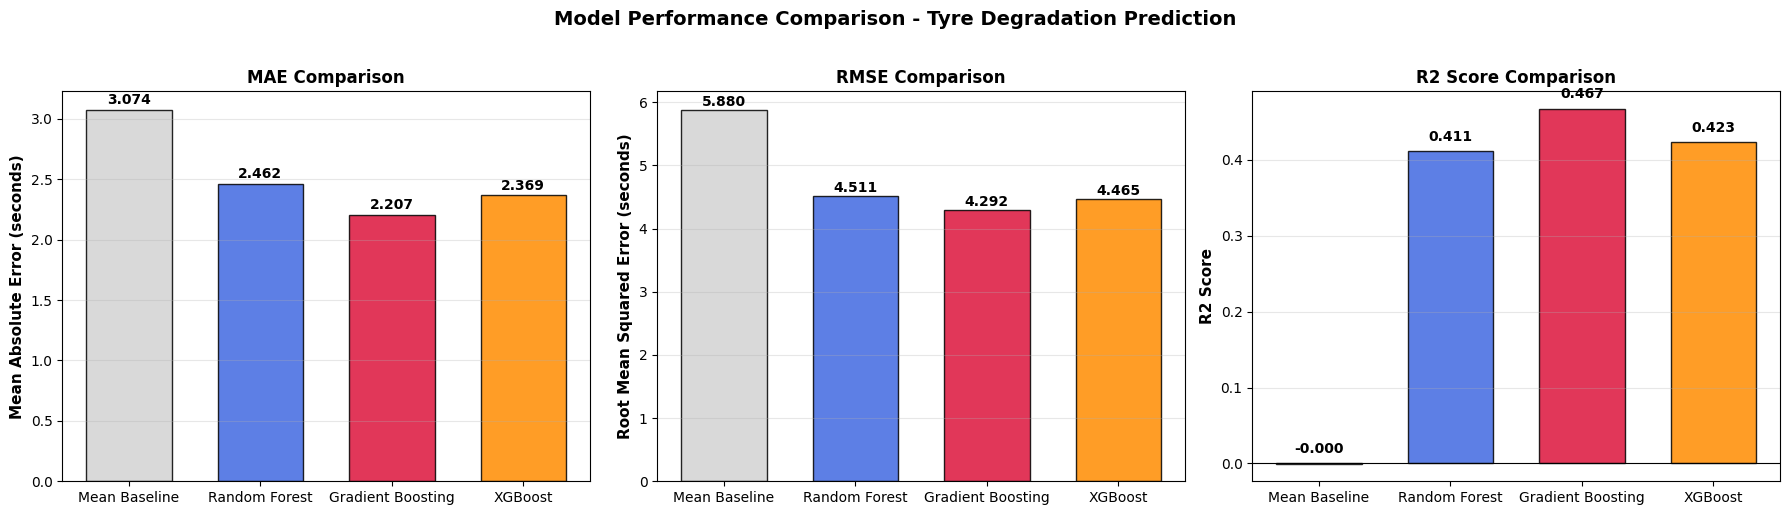

In [24]:
# Model Comparison for tyre degradation prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae]
rmse_scores = [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse]
r2_scores = [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ['lightgray', 'royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison
axes[2].bar(models, r2_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Tyre Degradation Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_tyre_degradation_model_comparison.png")

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

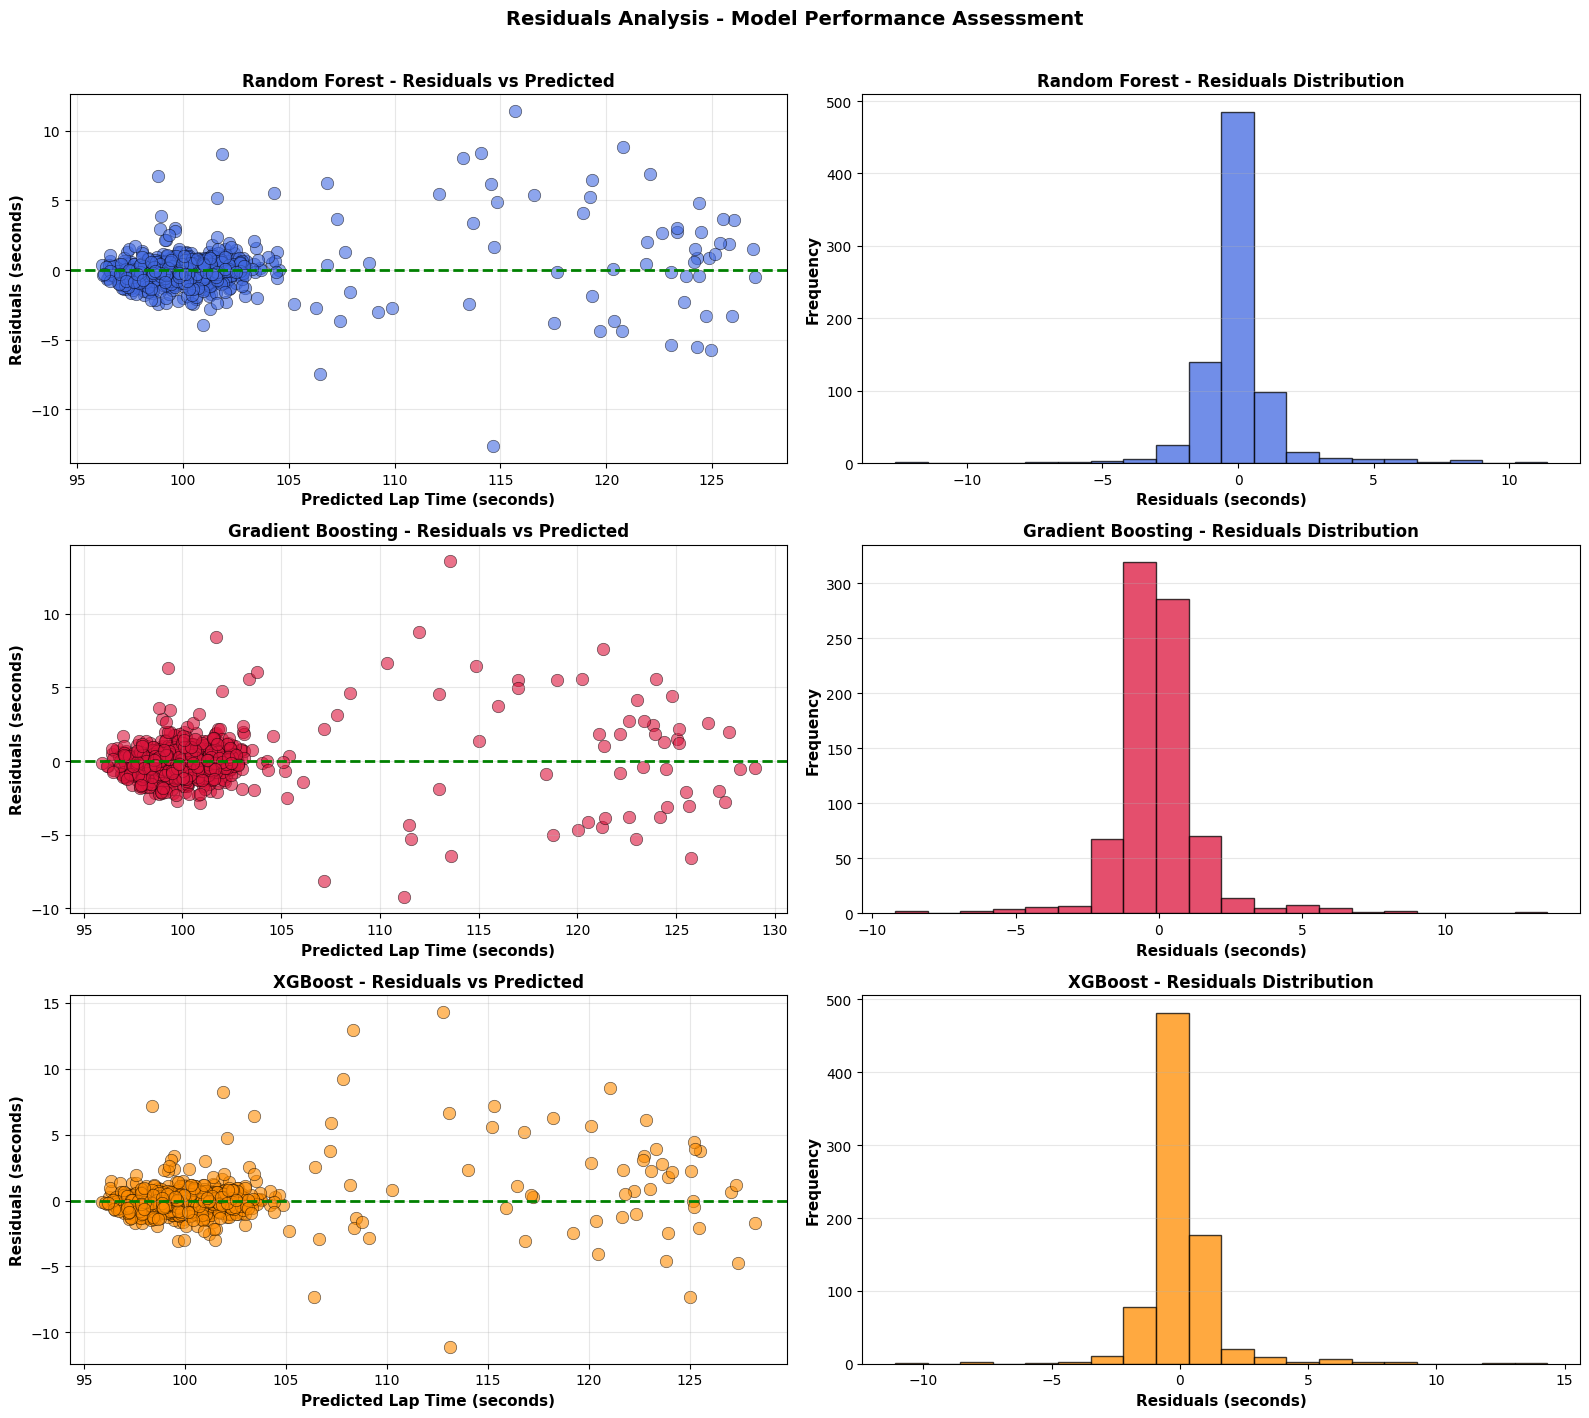

Random Forest - Mean Residuals: -0.0148, Std Dev: 1.5240
Gradient Boosting - Mean Residuals: -0.0104, Std Dev: 1.5884
XGBoost - Mean Residuals: 0.0579, Std Dev: 1.5584


In [25]:
# Residuals Analysis
rf_residuals = b_y_test - b_rf_predictions
gb_residuals = b_y_test - b_gb_predictions
xgb_residuals = b_y_test - b_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(b_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(b_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(b_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

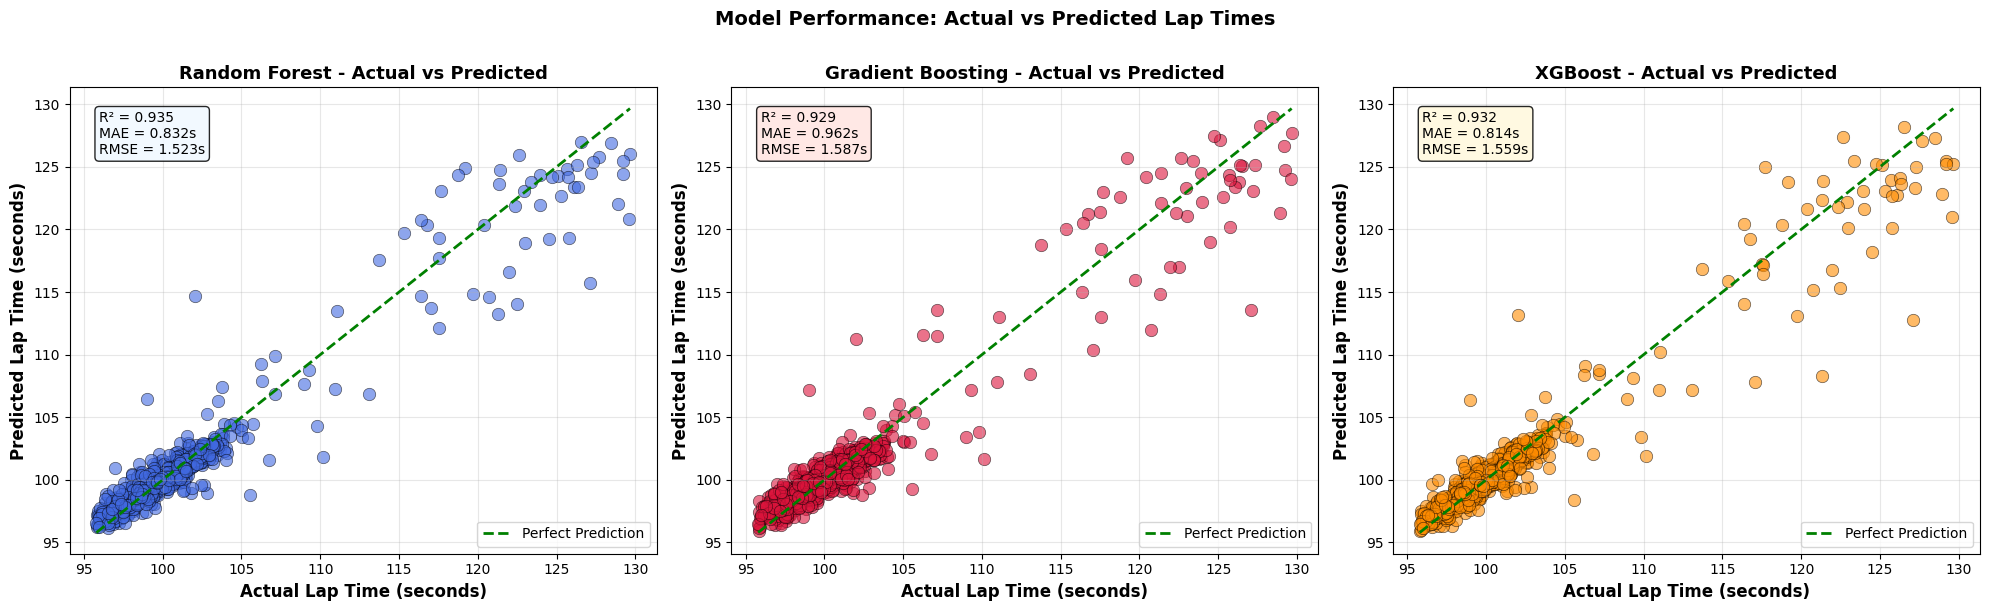

In [26]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(b_y_test, b_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(
    0.05, 0.95,
    f'R² = {b_rf_r2:.3f}\nMAE = {b_rf_mae:.3f}s\nRMSE = {b_rf_rmse:.3f}s',
    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
 )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(b_y_test, b_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(
    0.05, 0.95,
    f'R² = {b_gb_r2:.3f}\nMAE = {b_gb_mae:.3f}s\nRMSE = {b_gb_rmse:.3f}s',
    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
 )

# XGBoost: Actual vs Predicted
axes[2].scatter(b_y_test, b_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([b_y_test.min(), b_y_test.max()], [b_y_test.min(), b_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(
    0.05, 0.95,
    f'R² = {b_xgb_r2:.3f}\nMAE = {b_xgb_mae:.3f}s\nRMSE = {b_xgb_rmse:.3f}s',
    transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
 )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Team Consistency and Adaptation Projection

This scenario section uses each team's best validation model (with a global fallback) to estimate how modeled lap time changes as tyre life increases under controlled assumptions.

Treat the output as a team-consistency and adaptation sensitivity study rather than an exact single-lap forecast. It is most useful for comparing relative behavior under shared conditions.

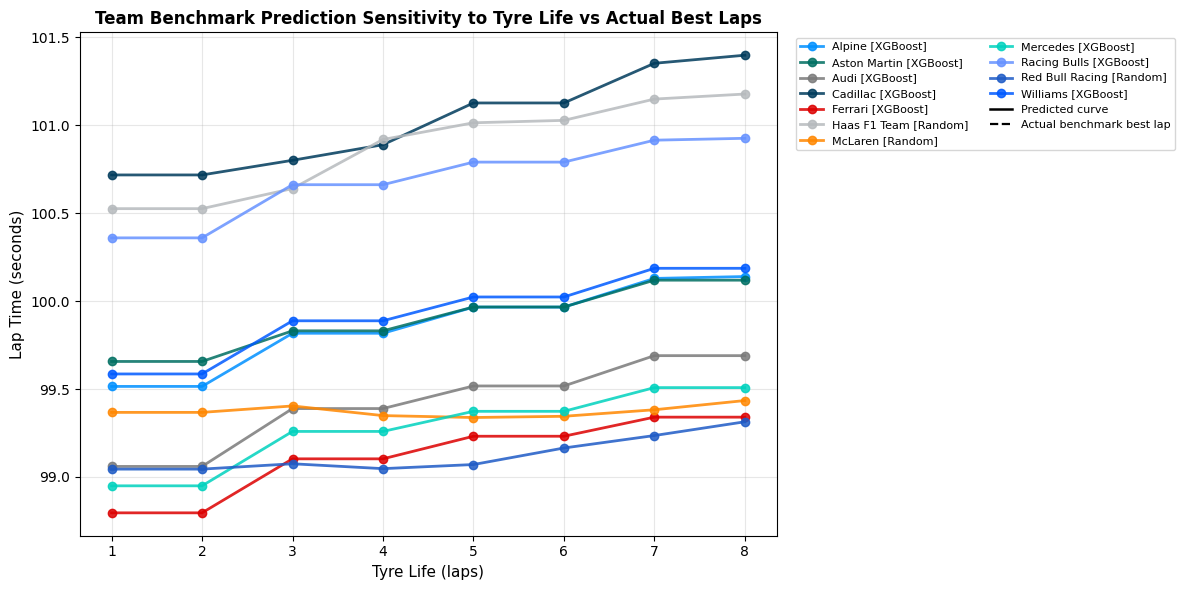

Global benchmark fallback model: Random Forest Regression
Teams with personalized model selection: 11
Best predicted benchmark lap by team:
           Team  TyreLife  PredictedLapTimeSec PredictedLapTime                ModelUsed
        Ferrari         2            98.796234         1:38.796       XGBoost Regression
       Mercedes         2            98.949806         1:38.950       XGBoost Regression
Red Bull Racing         1            99.044839         1:39.045 Random Forest Regression
           Audi         2            99.060081         1:39.060       XGBoost Regression
        McLaren         5            99.338107         1:39.338 Random Forest Regression
         Alpine         1            99.514931         1:39.515       XGBoost Regression
       Williams         1            99.585770         1:39.586       XGBoost Regression
   Aston Martin         1            99.656830         1:39.657       XGBoost Regression
   Racing Bulls         1           100.359421         1:40

In [27]:
# Format lap time in minutes:seconds.milliseconds
def format_lap_time(seconds: float) -> str:
    mins = int(seconds // 60)
    secs = seconds - mins * 60
    return f"{mins}:{secs:06.3f}"

# Build global and team-level model mapping
model_lookup = {
    'Random Forest Regression': b_rf_model,
    'Gradient Boosting Regression': b_gb_model,
    'XGBoost Regression': b_xgb_model
}

if b_rf_r2 >= b_gb_r2 and b_rf_r2 >= b_xgb_r2:
    global_model_name = 'Random Forest Regression'
elif b_gb_r2 >= b_rf_r2 and b_gb_r2 >= b_xgb_r2:
    global_model_name = 'Gradient Boosting Regression'
else:
    global_model_name = 'XGBoost Regression'

global_model = model_lookup[global_model_name]

team_best_model = {}
if 'b_team_mae' in globals() and isinstance(b_team_mae, pd.DataFrame) and not b_team_mae.empty:
    team_best_model = dict(zip(b_team_mae['Team'], b_team_mae['BestModel']))

# Use the most common track status as a benchmark-simulation default
if 'TrackStatus' in df.columns and df['TrackStatus'].notna().any():
    default_track_status = df['TrackStatus'].mode().iloc[0]
else:
    default_track_status = 1

# Build one representative row per team from the all-team benchmark data
team_profile = (df.groupby('Team',as_index=False).agg({
                    'Team': lambda x: x.mode().iloc[0],
                    'LapNumber': 'median',
                    'Stint': 'median',
                    'SpeedFL': 'median',
                    'Compound': lambda x: x.mode().iloc[0]
                    }))

team_profile = team_profile.copy()

tyre_life_range = list(range(1, 9))
sensitivity_rows = []

for _, row in team_profile.iterrows():
    for tyre_life in tyre_life_range:
        sensitivity_rows.append({'LapNumber': int(round(row['LapNumber'])), 
                                 'TyreLife': tyre_life,
                                 'Stint': int(round(row['Stint'])),
                                 'SpeedFL': float(row['SpeedFL']),
                                 'TrackStatus': default_track_status,
                                 'Compound': 'SOFT',
                                 'Team': row['Team'],
                                 })

sensitivity_df = pd.DataFrame(sensitivity_rows)

# Add the same simple training-baseline encodings used by the degradation model
global_median = float(df['LapTime'].median()) if 'LapTime' in df.columns else 0.0
team_median = df.groupby('Team')['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
compound_median = df.groupby('Compound')['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
team_compound_median = df.groupby(['Team', 'Compound'])['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)

def lookup_pair(series_a, series_b, lookup_series):
    return pd.Series(
        [lookup_series.get((a, b), np.nan) for a, b in zip(series_a, series_b)],
        index=series_a.index
    )

sensitivity_df['TeamMedianLapTime'] = sensitivity_df['Team'].map(team_median).fillna(global_median)
sensitivity_df['CompoundMedianLapTime'] = sensitivity_df['Compound'].map(compound_median).fillna(global_median)
sensitivity_df['TeamCompoundMedianLapTime'] = lookup_pair(sensitivity_df['Team'],
                                                          sensitivity_df['Compound'],
                                                          team_compound_median
        ).fillna(sensitivity_df['TeamMedianLapTime']).fillna(sensitivity_df['CompoundMedianLapTime']).fillna(global_median)

# Ensure all model features exist at prediction time, including telemetry/sector fields
required_prediction_features = list(b_features)
for col in required_prediction_features:
    if col in sensitivity_df.columns:
        continue

    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        series = pd.to_numeric(df[col], errors='coerce')
        sensitivity_df[col] = float(series.median()) if series.notna().any() else 0.0
    elif col in df.columns:
        mode_vals = df[col].dropna().mode()
        sensitivity_df[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else 'Unknown'
    elif col in ['Compound', 'Team', 'Session', 'FreshTyre']:
        defaults = {'Compound': 'Unknown', 'Team': 'Unknown'}
        sensitivity_df[col] = defaults.get(col, 'Unknown')
    else:
        sensitivity_df[col] = 0.0

# Predict with per-team best model when available, otherwise global fallback model.
def predict_benchmark_row(row: pd.Series) -> float:
    best_name = team_best_model.get(row['Team'], global_model_name)
    model = model_lookup.get(best_name, global_model)
    model_input = pd.DataFrame([row]).reindex(columns=required_prediction_features)
    return float(model.predict(model_input)[0])

sensitivity_df['PredictedLapTimeSec'] = sensitivity_df.apply(predict_benchmark_row, axis=1)
sensitivity_df['PredictedLapTime'] = sensitivity_df['PredictedLapTimeSec'].apply(format_lap_time)

if not pd.api.types.is_numeric_dtype(df['LapTime']):
    benchmark_laps = df.copy()
    benchmark_laps['LapTimeSec'] = pd.to_timedelta(benchmark_laps['LapTime'], errors='coerce').dt.total_seconds()
else:
    benchmark_laps = df.copy()
    benchmark_laps['LapTimeSec'] = pd.to_numeric(benchmark_laps['LapTime'], errors='coerce')

# Plot per-team curves
fig, ax = plt.subplots(figsize=(12, 6))

for _, row in team_profile.sort_values(['Team']).iterrows():
    team = row['Team']
    team_df = sensitivity_df[sensitivity_df['Team'] == team].sort_values('TyreLife')
    team_color = team_palette.get(team, 'gray')

    best_name = team_best_model.get(team, global_model_name)

    ax.plot(
        team_df['TyreLife'],
        team_df['PredictedLapTimeSec'],
        marker='o',
        linewidth=2.0,
        alpha=0.85,
        color=team_color,
        label=f"{team} [{best_name.split()[0]}]"
    )

ax.plot([], [], color='black', linewidth=1.8, label='Predicted curve')
ax.plot([], [], color='black', linestyle='--', linewidth=1.6, label='Actual benchmark best lap')
ax.set_xlabel('Tyre Life (laps)', fontsize=11)
ax.set_ylabel('Lap Time (seconds)', fontsize=11)
ax.set_title('Team Benchmark Prediction Sensitivity to Tyre Life vs Actual Best Laps', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_benchmark_sensitivity.png")

best_by_team = (
    sensitivity_df.sort_values('PredictedLapTimeSec')
    .groupby(['Team'], as_index=False)
    .first()[['Team', 'TyreLife', 'PredictedLapTimeSec', 'PredictedLapTime']]
    .sort_values('PredictedLapTimeSec')
)

if team_best_model:
    best_by_team['ModelUsed'] = best_by_team['Team'].map(team_best_model).fillna(global_model_name)
else:
    best_by_team['ModelUsed'] = global_model_name

print(f"Global benchmark fallback model: {global_model_name}")
print(f"Teams with personalized model selection: {len(team_best_model)}")
print('Best predicted benchmark lap by team:')
print(best_by_team.to_string(index=False))

The gap between modeled and observed lap times should be interpreted as a calibration and context-learning signal, not just a scorecard. Testing runs vary in fuel load, push intent, and setup experimentation, so absolute offsets are expected during baseline phases.

For that reason, relative ordering, trend stability, and consistency across tyre-life windows are often more informative than raw absolute differences in early preseason analysis.

#### Team Pace Index (% of Constructor Champion)

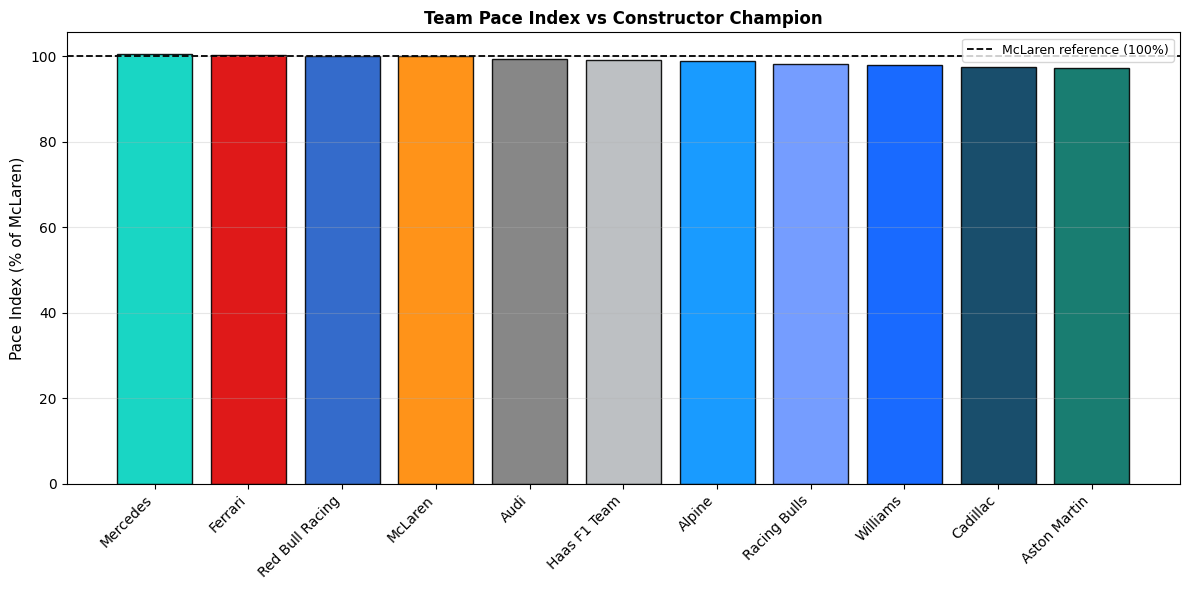


Pace index, % of McLaren (100%), fixed at TyreLife=4, Stint=1, Compound=SOFT, using Gradient Boosting Regression:
           Team  PredictedPace_sec  PaceIndex_vs_ConstructorChampion
       Mercedes          98.745335                            100.58
        Ferrari          99.010167                            100.31
Red Bull Racing          99.307738                            100.01
        McLaren          99.313756                            100.00
           Audi          99.828861                             99.48
   Haas F1 Team         100.128930                             99.19
         Alpine         100.455651                             98.86
   Racing Bulls         101.030686                             98.30
       Williams         101.371299                             97.97
       Cadillac         101.840513                             97.52
   Aston Martin         102.045903                             97.32


In [28]:
REFERENCE_STINT = 1
REFERENCE_TYRE_LIFE = 4
REFERENCE_COMPOUND = 'SOFT'

non_telemetry_cols = ['LapNumber', 'TyreLife', 'Stint', 'Test',
                       'Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
b_telemetry_features = [col for col in b_features if col not in non_telemetry_cols]

def build_team_benchmark_inputs(reference_tyre_life=REFERENCE_TYRE_LIFE,
                                 reference_stint=REFERENCE_STINT,
                                 reference_compound=REFERENCE_COMPOUND):
    
    reference_df = b_model_df.copy()

    reference_lap_number = int(reference_df['LapNumber'].median())
    reference_session = reference_df['Session'].mode().iloc[0]
    reference_track_status = reference_df['TrackStatus'].mode().iloc[0]
    reference_test = int(reference_df['Test'].mode().iloc[0])

    rows = []
    for _, driver_team in reference_df[['Driver', 'Team']].drop_duplicates().iterrows():
        driver = driver_team['Driver']
        team = driver_team['Team']
        driver_rows = reference_df[reference_df['Driver'] == driver]

        row = {
            'LapNumber': reference_lap_number,
            'TyreLife': reference_tyre_life,
            'Stint': reference_stint,
            'Test': reference_test,
            'Compound': reference_compound,
            'Driver': driver,
            'Team': team,
            'Session': reference_session,
            'TrackStatus': reference_track_status
        }

        for col in b_telemetry_features:
            driver_vals = pd.to_numeric(driver_rows[col], errors='coerce')
            if driver_vals.notna().any():
                row[col] = float(driver_vals.median())
            else:
                overall_vals = pd.to_numeric(reference_df[col], errors='coerce')
                row[col] = float(overall_vals.median()) if overall_vals.notna().any() else 0.0

        rows.append(row)

    return pd.DataFrame(rows).reindex(columns=b_features)

pred_model_map = {
    'Random Forest Regression': b_rf_model,
    'Gradient Boosting Regression': b_gb_model,
    'XGBoost Regression': b_xgb_model
}

team_pace = pd.DataFrame()

if best_model in pred_model_map:
    chosen_model = pred_model_map[best_model]
    team_benchmark_inputs = build_team_benchmark_inputs()
    team_benchmark_inputs['PredLapTime_sec'] = chosen_model.predict(team_benchmark_inputs)

    team_pace = (team_benchmark_inputs.groupby('Team')['PredLapTime_sec'].mean().rename('PredictedPace_sec').reset_index())

    if constructor_champion in team_pace['Team'].values:
        reference_pace = team_pace.loc[
            team_pace['Team'] == constructor_champion, 'PredictedPace_sec'
        ].iloc[0]
        team_pace['PaceIndex_vs_ConstructorChampion'] = (
            reference_pace / team_pace['PredictedPace_sec'] * 100
        ).round(2)
        team_pace = team_pace.sort_values(
            'PaceIndex_vs_ConstructorChampion', ascending=False
        ).reset_index(drop=True)
    else:
        print(f"\nWarning: reference team '{constructor_champion}' not present in the "
              f"training data; pace benchmarking skipped.")
else:
    print("\nGlobal benchmark models tied on R²; skipping pace benchmarking.")

# Plot first, matching the "Best predicted benchmark lap by team" cell pattern above
if not team_pace.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_colors = [team_palette.get(t, '#4C72B0') for t in team_pace['Team']]

    ax.bar(
        team_pace['Team'], team_pace['PaceIndex_vs_ConstructorChampion'],
        color=bar_colors, edgecolor='black', alpha=0.9
    )
    ax.axhline(100, color='black', linestyle='--', linewidth=1.3,
               label=f'{constructor_champion} reference (100%)')
    ax.set_xticks(range(len(team_pace)))
    ax.set_xticklabels(team_pace['Team'], rotation=45, ha='right')
    ax.set_ylabel('Pace Index (% of ' + constructor_champion + ')', fontsize=11)
    ax.set_title('Team Pace Index vs Constructor Champion',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_tag}_team_pace_index.png")

    print(f"\nPace index, % of {constructor_champion} (100%), fixed at "
          f"TyreLife={REFERENCE_TYRE_LIFE}, Stint={REFERENCE_STINT}, "
          f"Compound={REFERENCE_COMPOUND}, using {best_model}:")
    print(team_pace.to_string(index=False))
else:
    print("\nSkipping pace index plot: pace index table is empty.")

## Tyre Behaviour and Degradation Modelling

This section focuses on compound-level tyre behaviour in Bahrain Preseason Testing 1 & 2. Using degradation trends from FP-style long-run data, the analysis estimates lap-time evolution across stint structures and highlights where drivers and teams diverge in degradation management.

> **Note:** Degradation rates are fitted on laps with TyreLife > 3 (warm-up phase excluded). Pit stop loss and safety-car effects are not the objective in this section; the focus is tyre trend understanding and benchmark comparability.

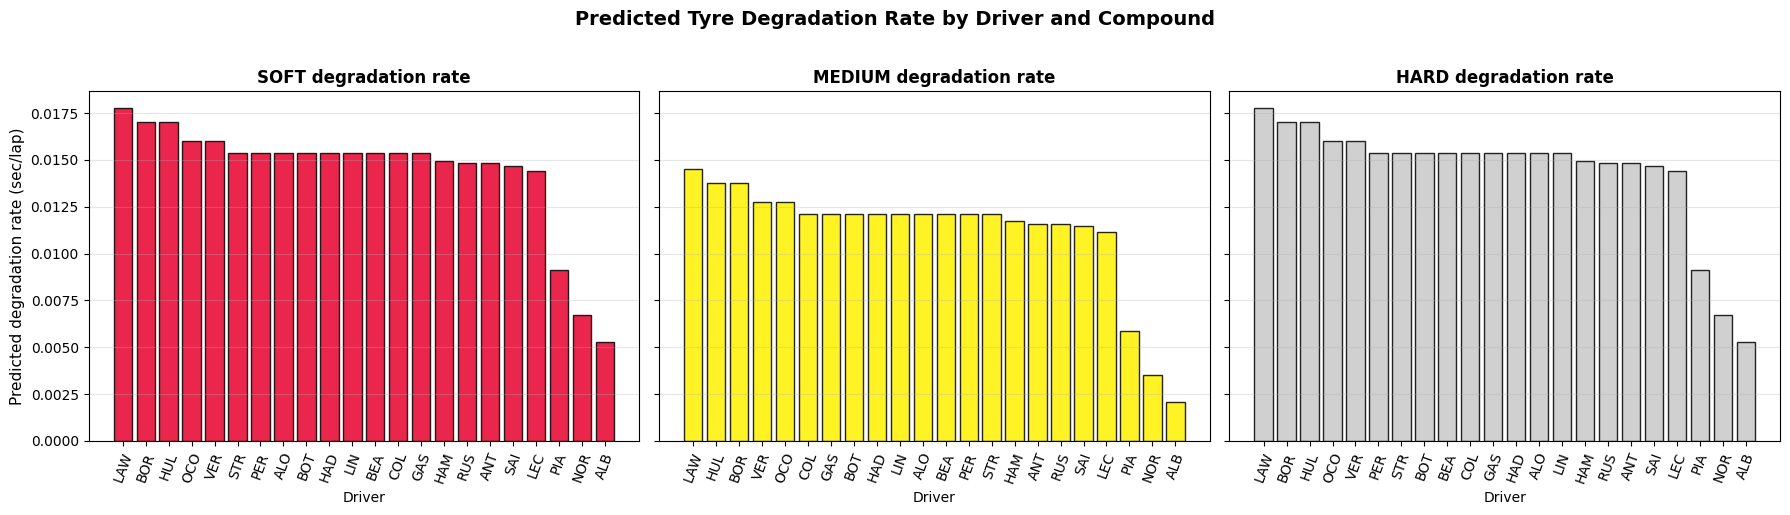

Degradation-rate analysis model: Gradient Boosting (Tyre Degradation) (R2 = 0.467)

Predicted degradation rate table (sec/lap):
           Team Driver Compound  DegradationRate_sec_per_lap  PredLapTime_Lap4  PredLapTime_Lap30
   Racing Bulls    LAW     HARD                       0.0178            98.979             99.847
           Audi    BOR     HARD                       0.0170            99.207            100.052
           Audi    HUL     HARD                       0.0170            98.428             99.273
   Haas F1 Team    OCO     HARD                       0.0160            96.111             96.921
Red Bull Racing    VER     HARD                       0.0160            96.086             96.897
       Cadillac    PER     HARD                       0.0154           101.668            102.464
   Aston Martin    STR     HARD                       0.0154           100.399            101.195
       Cadillac    BOT     HARD                       0.0154           100.283          

In [29]:
# Degradation-rate analysis (race-strategy block removed)
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
compound_colors = {'SOFT': '#E8002D', 'MEDIUM': '#FFF200', 'HARD': '#C8C8C8'}

# Select best tyre degradation model by validation R2
if t_rf_r2 >= t_gb_r2 and t_rf_r2 >= t_xgb_r2:
    degrad_model = t_rf_model
    degrad_model_name = 'Random Forest (Tyre Degradation)'
elif t_gb_r2 >= t_rf_r2 and t_gb_r2 >= t_xgb_r2:
    degrad_model = t_gb_model
    degrad_model_name = 'Gradient Boosting (Tyre Degradation)'
else:
    degrad_model = t_xgb_model
    degrad_model_name = 'XGBoost (Tyre Degradation)'

# Build representative driver context from available sessions in this dataset
available_sessions = df['Session'].dropna().astype(str).unique().tolist() if 'Session' in df.columns else []
analysis_sessions = [s for s in ['Day1', 'Day2', 'Day3'] if s in available_sessions]
if not analysis_sessions:
    analysis_sessions = available_sessions

driver_profile_ml = (
    df[
        df['Session'].astype(str).isin(analysis_sessions)
        & df['LapTime'].notna()
        & (pd.to_numeric(df['TyreLife'], errors='coerce') > 1)
    ]
    .groupby('Driver', as_index=False)
    .agg({
        'Team': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
        'LapNumber': lambda x: x.median() if len(x.dropna()) else 0,
        'Stint': lambda x: x.median() if len(x.dropna()) else 0,
        'SpeedST': lambda x: x.median() if len(x.dropna()) else 0.0,
        'TrackStatus': lambda x: x.mode().iloc[0] if not x.mode().empty else 1,
        'FreshTyre': lambda x: 'False'
    })
)
driver_profile_ml = driver_profile_ml.copy().reset_index(drop=True)

if driver_profile_ml.empty:
    raise ValueError('No driver rows available to estimate degradation rates. Check Session and TyreLife columns.')

driver_context = driver_profile_ml.set_index('Driver').to_dict(orient='index')

# Shared medians for robust feature fallback
global_median = float(df['LapTime'].median()) if 'LapTime' in df.columns else 0.0
driver_median = df.groupby('Driver')['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
team_median = df.groupby('Team')['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
compound_median = df.groupby('Compound')['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
driver_compound_median = df.groupby(['Driver', 'Compound'])['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)
team_compound_median = df.groupby(['Team', 'Compound'])['LapTime'].median() if 'LapTime' in df.columns else pd.Series(dtype=float)

def lookup_pair(series_a, series_b, lookup_series):
    return pd.Series(
        [lookup_series.get((a, b), np.nan) for a, b in zip(series_a, series_b)],
        index=series_a.index
    )

def build_degradation_inputs(driver: str, compound: str, tyre_life_values):
    ctx = driver_context.get(driver, {})
    lap_number = int(round(float(ctx.get('LapNumber', 0)))) if pd.notna(ctx.get('LapNumber', 0)) else 0
    stint_number = int(round(float(ctx.get('Stint', 0)))) if pd.notna(ctx.get('Stint', 0)) else 0
    speed_st = float(ctx.get('SpeedST', 0.0)) if pd.notna(ctx.get('SpeedST', 0.0)) else 0.0
    track_status = ctx.get('TrackStatus', 1)
    team = ctx.get('Team', 'Unknown')

    rows = []
    for tyre_life in tyre_life_values:
        tyre_life = int(tyre_life)
        rows.append({
            'LapNumber': lap_number,
            'TyreLife': tyre_life,
            'Stint': stint_number,
            'SpeedST': speed_st,
            'TrackStatus': track_status,
            'Compound': compound,
            'Driver': driver,
            'Team': team,
            'Session': analysis_sessions[0],
            'FreshTyre': 'False'
        })

    input_df = pd.DataFrame(rows)

    # Add required model features dynamically with safe defaults
    for col in t_features:
        if col in input_df.columns:
            continue
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            col_values = pd.to_numeric(df[col], errors='coerce')
            input_df[col] = float(col_values.median()) if col_values.notna().any() else 0.0
        elif col in df.columns:
            mode_vals = df[col].dropna().mode()
            input_df[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else 'Unknown'
        else:
            input_df[col] = 0.0

    # Add target encoding style features expected by degradation models
    input_df['DriverMedianLapTime'] = input_df['Driver'].map(driver_median).fillna(global_median)
    input_df['TeamMedianLapTime'] = input_df['Team'].map(team_median).fillna(global_median)
    input_df['CompoundMedianLapTime'] = input_df['Compound'].map(compound_median).fillna(global_median)
    input_df['DriverCompoundMedianLapTime'] = lookup_pair(
        input_df['Driver'], input_df['Compound'], driver_compound_median
    ).fillna(input_df['DriverMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)
    input_df['TeamCompoundMedianLapTime'] = lookup_pair(
        input_df['Team'], input_df['Compound'], team_compound_median
    ).fillna(input_df['TeamMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)

    return input_df.reindex(columns=t_features)

# Predict lap-time evolution vs tyre life and estimate degradation rates
tyre_life_values = list(range(4, 31))  # Skip warm-up-heavy first laps
degradation_curves = []
degradation_rates = []

for driver in sorted(driver_context.keys()):
    team = driver_context[driver]['Team']
    for compound in COMPOUNDS:
        model_input = build_degradation_inputs(driver, compound, tyre_life_values)
        y_pred = degrad_model.predict(model_input)

        curve_df = pd.DataFrame({
            'Driver': driver,
            'Team': team,
            'Compound': compound,
            'TyreLife': tyre_life_values,
            'PredLapTimeSec': y_pred
        })
        degradation_curves.append(curve_df)

        # Linear slope as degradation rate (seconds per lap) on the analyzed window
        slope, _ = np.polyfit(curve_df['TyreLife'], curve_df['PredLapTimeSec'], 1)
        degradation_rates.append({
            'Driver': driver,
            'Team': team,
            'Compound': compound,
            'DegradationRate_sec_per_lap': float(slope),
            'PredLapTime_Lap4': float(curve_df.loc[curve_df['TyreLife'] == 4, 'PredLapTimeSec'].iloc[0]),
            'PredLapTime_Lap30': float(curve_df.loc[curve_df['TyreLife'] == 30, 'PredLapTimeSec'].iloc[0])
        })

degradation_curve_df = pd.concat(degradation_curves, ignore_index=True)
degradation_rate_df = pd.DataFrame(degradation_rates).sort_values(
    ['Compound', 'DegradationRate_sec_per_lap'], ascending=[True, False]
).reset_index(drop=True)

# Visualize driver-level degradation-rate distribution by compound
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, compound in enumerate(COMPOUNDS):
    plot_df = degradation_rate_df[degradation_rate_df['Compound'] == compound].copy()
    plot_df = plot_df.sort_values('DegradationRate_sec_per_lap', ascending=False)
    axes[i].bar(
        plot_df['Driver'],
        plot_df['DegradationRate_sec_per_lap'],
        color=compound_colors.get(compound, 'gray'),
        edgecolor='black',
        alpha=0.85
    )
    axes[i].set_title(f'{compound} degradation rate', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Driver', fontsize=10)
    axes[i].tick_params(axis='x', rotation=70)
    axes[i].grid(alpha=0.3, axis='y')

axes[0].set_ylabel('Predicted degradation rate (sec/lap)', fontsize=11)
plt.suptitle('Predicted Tyre Degradation Rate by Driver and Compound', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_tag}_team_tyre_degradation_rate.png")

print(f"Degradation-rate analysis model: {degrad_model_name} (R2 = {max(t_rf_r2, t_gb_r2, t_xgb_r2):.3f})")
print('\nPredicted degradation rate table (sec/lap):')
print(
    degradation_rate_df[['Team', 'Driver', 'Compound', 'DegradationRate_sec_per_lap', 'PredLapTime_Lap4', 'PredLapTime_Lap30']]
    .round({'DegradationRate_sec_per_lap': 4, 'PredLapTime_Lap4': 3, 'PredLapTime_Lap30': 3})
    .to_string(index=False)
)

## Conclusion

This notebook delivers an end-to-end workflow for Bahrain Preseason Testing 1 & 2 analysis using FP-style sessions. It covers data extraction, cleaning, all-team filtering, exploratory diagnostics, and model benchmarking aligned to baseline performance understanding.

The analysis shows that lap time is shaped by multiple interacting factors rather than any single dominant variable. Tyre condition, session context, stint progression, and straight-line speed all matter, but their combined effect is more informative than isolated averages.

The final outputs support three practical outcomes: baseline car performance benchmarking, driver consistency and adaptation profiling, and tyre behaviour/degradation modelling for engineering insight.

### Key Findings

1. Baseline pace varies not only by team but by session structure, stint pattern, and lap context, so raw averages alone are incomplete.
2. Tyre compound and tyre life materially influence lap time, but the signal becomes more useful when modeled with context-aware features.
3. Ensemble models outperform naive baselines, confirming that the feature set captures actionable performance structure.
4. Driver-level adaptation can be profiled through stability, trend convergence, and tyre-life sensitivity across sessions.

### Recommendations

#### For Performance Engineering

1. Use baseline model outputs as comparative engineering indicators, not absolute single-lap truth.
2. Prioritize relative team and driver deltas when absolute offsets are still converging in preseason conditions.
3. Pair tyre-life sensitivity results with run-plan context to avoid over-interpreting isolated laps.

#### For Data Science

1. Segment baseline, adaptation, and degradation contexts more explicitly to reduce systematic bias across run types.
2. Add richer inputs such as sector splits, mini-sector traces, traffic indicators, and weather or track evolution variables.
3. Compare model quality not only on point accuracy but also on calibration and stability across sessions.

#### For Driver Adaptation Analysis

1. Use projection outputs as scenario guidance for adaptation trends, not deterministic single-lap truth.
2. Pair pace estimates with uncertainty ranges when comparing setup or tyre-age alternatives.
3. Revisit comparisons after each session update so adaptation conclusions reflect the latest data.

#### Next Analysis Steps

1. Extend the dataset with additional Bahrain testing runs and comparable preseason sessions for stronger baseline robustness.
2. Evaluate additional algorithms or tuned variants, including a fuller XGBoost diagnostic pass and calibrated ensemble comparisons.
3. Add uncertainty-aware outputs such as prediction intervals or quantile models for decision support.
4. Test both shared and driver-specific models to measure where specialization improves consistency and degradation forecasts.